###  Исследовательская работа рынка недвижимости
### Выполнил: Казымов Эмиль Эльмир оглы, 3 курс, СПБГЭУ

Описание датасета
Каждая строка - уникальное объявление, идентификатор объявление удален.
date - дата объявления
region - Регион
building_type - Тип дома 0 - Другое. 1 - Панельный. 2 - Кирпично-монолитный. 3 - Кирпичный. 4 - Блочный 5 - Деревянный
object_type -  1 - Вторичный рынок; 11 - Первичный рынок;
level - Этаж
levels - Число этажей
rooms - Число комнат, где -1 означает студия
area - Общая площадь
kitchen_area - Площадь кухни
price - Цена в руб.

### Пункт №1. Предобработка данных

In [1]:
# импортируем различные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="darkgrid", rc={"figure.figsize": (12, 8)}, font_scale=1.2)

In [2]:
# загружаем файл с данными
data = pd.read_csv('realty_18_21.csv')

In [3]:
data

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,11
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1
...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,11
5477002,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,11
5477003,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1
5477004,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,11


In [4]:
# выводим первые 5 строк
data.head()

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,11
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1


In [5]:
# выводим инф-цию о типах данных
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   price          int64  
 1   date           object 
 2   region         int64  
 3   building_type  int64  
 4   level          int64  
 5   levels         int64  
 6   rooms          int64  
 7   area           float64
 8   kitchen_area   float64
 9   object_type    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 417.9+ MB


### Пункт №2. Добавление информации из датасета region.csv. 

In [6]:
# загружаем вспомогательный файл с данными
data_dop = pd.read_csv('region.csv')

In [7]:
# выводим первые 5 строк
data_dop.head()

,code,reg_name
0,2661,Санкт-Петербург
1,3446,Ленинградская область
2,3,Москва
3,81,Московская область
4,2843,Краснодарский край


In [8]:
# выводим инф-цию о типах данных
data_dop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   code      83 non-null     object
 1   reg_name  83 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB


In [9]:
# меняем названия столбцов
data_dop.columns = ['region','reg_name']
data_dop

,region,reg_name
0,2661,Санкт-Петербург
1,3446,Ленинградская область
2,3,Москва
3,81,Московская область
4,2843,Краснодарский край
...,...,...
78,16705,Магаданская область
79,69,Еврейская автономная область
80,4963,Приморский край
81,1901,Сахалинская область


In [10]:
# выводим названия столбцов
q1 = data.columns
q1

Index(['price', 'date', 'region', 'building_type', 'level', 'levels', 'rooms',
       'area', 'kitchen_area', 'object_type'],
      dtype='object')

In [11]:
# меняем тип, чтобы в дальнейшем объединить два датасета
data['region'] = data['region'].astype('str')

In [12]:
# ищем ошибку в данных
data['region'].unique()

array(['2661', '81', '2871', '2843', '3', '3106', '2922', '2900', '2722',
       '6171', '3230', '4417', '5282', '5368', '3446', '5520', '6817',
       '9579', '2604', '1010', '9648', '7793', '13919', '2860', '3019',
       '4982', '5241', '3870', '3991', '2359', '9654', '2072', '8090',
       '4007', '11171', '10160', '7873', '2594', '8509', '11416', '11991',
       '2880', '5178', '13913', '6309', '5952', '6543', '2328', '5993',
       '2484', '13098', '4240', '5789', '1901', '14880', '10201', '1491',
       '2885', '5794', '2528', '4374', '4695', '5143', '6937', '2806',
       '14368', '5736', '7121', '4086', '821', '10582', '7896', '8640',
       '5703', '8894', '4249', '3153', '4189', '2814', '7929', '16705',
       '69', '4963', '61888'], dtype=object)

In [13]:
# ищем ошибку в данных
data['count_pr'] = data['region'].astype(str).str.split(',').str.len()

In [14]:
# ищем ошибку в данных
data.query('count_pr>1')

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,count_pr


In [15]:
# ищем ошибку в данных
data_dop['reg_name'].unique()

array(['Санкт-Петербург', 'Ленинградская область', 'Москва',
       'Московская область', 'Краснодарский край',
       'Нижегородская область', 'Ростовская область', 'Самарская область',
       'Республика Татарстан', 'Ставропольский край',
       'Республика Башкортостан', 'Свердловская область',
       'Республика Коми', 'Челябинская область', 'Иркутская область',
       'Пермский край', 'Алтайский край', 'Республика Бурятия',
       'Ярославская область', 'Удмуртская Республика',
       'Псковская область', 'Республика Северная Осетия — Алания',
       'Кемеровская область', 'Чувашская Республика',
       'Республика Марий Эл', 'Кабардино-Балкарская Республика',
       'Республика Мордовия', 'Красноярский край', 'Тюменская область',
       'Республика Хакасия', 'Новосибирская область',
       'Воронежская область', 'Республика Карелия', 'Республика Дагестан',
       'Республика Саха (Якутия)', 'Забайкальский край',
       'Республика Крым', 'Кировская область', 'Республика Калмыкия'

In [16]:
# ищем ошибку в данных
data_dop['region'].unique()

array(['2661', '3446', '3', '81', '2843', '2871', '3230', '3106', '2922',
       '2900', '2722', '6171', '4417', '5282', '5368', '5520', '6817',
       '9579', '2604', '1010', '7793', '13919', '2860', '3019', '4982',
       '9648', '5241', '3870', '3991', '2359', '9654', '2072', '8090',
       '4007', '11171', '10160', '7873, 6937', '2594', '8509', '11416',
       '11991', '5178', '13913', '6309', '5952', '6543', '2880', '5993',
       '2484', '4240', '5789', '14880', '1491', '2885', '5794', '2528',
       '4374', '4695', '2328', '5143', '2806', '14368', '5736', '7121',
       '4086', '821', '10582', '7896', '8640', '5703', '10201', '4249',
       '3153', '4189', '2814', '13098', '8894', '7929', '16705', '69',
       '4963', '1901', '61888'], dtype=object)

In [17]:
# ищем ошибку в данных
data_dop['region'].unique()

array(['2661', '3446', '3', '81', '2843', '2871', '3230', '3106', '2922',
       '2900', '2722', '6171', '4417', '5282', '5368', '5520', '6817',
       '9579', '2604', '1010', '7793', '13919', '2860', '3019', '4982',
       '9648', '5241', '3870', '3991', '2359', '9654', '2072', '8090',
       '4007', '11171', '10160', '7873, 6937', '2594', '8509', '11416',
       '11991', '5178', '13913', '6309', '5952', '6543', '2880', '5993',
       '2484', '4240', '5789', '14880', '1491', '2885', '5794', '2528',
       '4374', '4695', '2328', '5143', '2806', '14368', '5736', '7121',
       '4086', '821', '10582', '7896', '8640', '5703', '10201', '4249',
       '3153', '4189', '2814', '13098', '8894', '7929', '16705', '69',
       '4963', '1901', '61888'], dtype=object)

In [18]:
# ищем ошибку в данных
data_dop['count_pr'] = data_dop['region'].astype(str).str.split(',').str.len()

In [19]:
# ищем ошибку в данных
data_dop.query('count_pr>1')

,region,reg_name,count_pr
36,"7873, 6937",Республика Крым,2


In [20]:
# исправляем ошибку в данных
data_dop.loc[len(data_dop)] = {'region': '7873', 'reg_name':'Республика Крым','count_nums':1}
data_dop.loc[len(data_dop)] = {'region': '6937', 'reg_name':'Республика Крым','count_nums':1}

In [21]:
# удаляем строку с ошибкой из вспомгательного датасета
data_dop = data_dop.drop(index=36)

In [22]:
# добавляем из вспомогательного датасета в основной информацию
data = data.merge(data_dop[['region', 'reg_name']], 
                  on='region',how='left')

In [23]:
# удаляем ненужные столбцы
data = data.drop(columns=['count_pr'])

In [24]:
# выводим данные, чтобы убедиться в правильности
data

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,11,Краснодарский край
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область
...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,11,Москва
5477002,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,11,Москва
5477003,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1,Нижегородская область
5477004,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,11,Москва


#### Вывод по пункту №2:
1. Вспомогательный датасет был добавлен и изучен. В нем были найдены ошибки: в одной строке было 2 кода региона. Строка была разделены на 2 строчки, а исходная удалена. Кроме того, тип данных в исходном и вспомогательном датасете не совподали, из-за чего нельзя было бы применить функцию merge: в нсоновм датасете столбец с данными о коде региона был с типом "int", а в вспомогательном с типом "object". Поэтому столбец с кодом региона был преобразован в тип данных "object" при помощи функции astype*
2. Далее оба датасета - исходный и вспомогательный - были проверены на аномалии и ошибки через ращличные функции. Больше ошибок в данных не было найдено;
3. Через функцию merge данные из вспомогательного датасета добавлены в исходный. Теперь в основном датасете есть информация о названии региона.

In [25]:
# выводим количество пропусков в кажом столбце
data.isnull().sum()

price                 0
date                  0
region                0
building_type         0
level                 0
levels                0
rooms                 0
area                  0
kitchen_area     253711
object_type           0
reg_name              0
dtype: int64

In [26]:
# выводим инф-цию о типах данных
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   price          int64  
 1   date           object 
 2   region         object 
 3   building_type  int64  
 4   level          int64  
 5   levels         int64  
 6   rooms          int64  
 7   area           float64
 8   kitchen_area   float64
 9   object_type    int64  
 10  reg_name       object 
dtypes: float64(2), int64(6), object(3)
memory usage: 459.6+ MB


In [27]:
# меняем тип данных и добавляем новые столбцы в годом и месяцем
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

In [28]:
# выводим данные, чтобы убедиться в правильности
data

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург,2018,2
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область,2018,2
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область,2018,2
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,11,Краснодарский край,2018,3
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область,2018,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,11,Москва,2021,5
5477002,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,11,Москва,2021,5
5477003,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1,Нижегородская область,2021,5
5477004,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,11,Москва,2021,5


In [29]:
# выводим инф-цию о типах данных для проверки
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 13 columns):
 #   Column         Dtype         
---  ------         -----         
 0   price          int64         
 1   date           datetime64[ns]
 2   region         object        
 3   building_type  int64         
 4   level          int64         
 5   levels         int64         
 6   rooms          int64         
 7   area           float64       
 8   kitchen_area   float64       
 9   object_type    int64         
 10  reg_name       object        
 11  year           int32         
 12  month          int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(6), object(2)
memory usage: 501.4+ MB


In [30]:
# смотрим уникальные значения каждого столбца и находим аномалии
for n in q1:
    q2 = data[n].unique()
    print(q2)

[ 6050000  8650000  4000000 ... 12503160 11831910 13316200]
<DatetimeArray>
['2018-02-19 00:00:00', '2018-02-27 00:00:00', '2018-02-28 00:00:00',
 '2018-03-01 00:00:00', '2018-03-02 00:00:00', '2018-03-04 00:00:00',
 '2018-03-05 00:00:00', '2018-03-06 00:00:00', '2018-03-12 00:00:00',
 '2018-03-15 00:00:00',
 ...
 '2021-04-22 00:00:00', '2021-04-23 00:00:00', '2021-04-24 00:00:00',
 '2021-04-25 00:00:00', '2021-04-26 00:00:00', '2021-04-27 00:00:00',
 '2021-04-28 00:00:00', '2021-04-29 00:00:00', '2021-04-30 00:00:00',
 '2021-05-01 00:00:00']
Length: 1075, dtype: datetime64[ns]
['2661' '81' '2871' '2843' '3' '3106' '2922' '2900' '2722' '6171' '3230'
 '4417' '5282' '5368' '3446' '5520' '6817' '9579' '2604' '1010' '9648'
 '7793' '13919' '2860' '3019' '4982' '5241' '3870' '3991' '2359' '9654'
 '2072' '8090' '4007' '11171' '10160' '7873' '2594' '8509' '11416' '11991'
 '2880' '5178' '13913' '6309' '5952' '6543' '2328' '5993' '2484' '13098'
 '4240' '5789' '1901' '14880' '10201' '1491' '2885'

In [31]:
# ищем явные дуликаты
data.duplicated().sum()

np.int64(235655)

In [32]:
# выводим явные дубликаты
data.loc[data.duplicated(keep=False)]

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month
402,1300000,2018-09-08,9654,1,5,10,1,41.36,10.88,11,Новосибирская область,2018,9
403,1750000,2018-09-08,9654,1,9,10,1,58.03,17.00,1,Новосибирская область,2018,9
420,1050000,2018-09-08,9654,1,3,10,1,33.58,5.00,1,Новосибирская область,2018,9
421,1700000,2018-09-08,9654,1,1,10,1,58.03,17.00,1,Новосибирская область,2018,9
433,940240,2018-09-08,9654,1,4,10,1,33.58,5.00,11,Новосибирская область,2018,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475660,5000000,2021-05-01,3991,1,7,9,3,65.00,8.60,1,Тюменская область,2021,5
5475971,3900000,2021-05-01,2604,3,4,10,2,48.00,9.00,1,Ярославская область,2021,5
5476318,5280000,2021-05-01,2661,2,14,18,1,44.00,10.00,1,Санкт-Петербург,2021,5
5476380,6400000,2021-05-01,3991,3,6,9,2,87.00,19.50,1,Тюменская область,2021,5


In [33]:
# удаляем явные дубликаты
data.drop_duplicates(inplace=True)

In [34]:
# проверяем
data.duplicated().sum()

np.int64(0)

[Text(0.5, 1.0, 'Разброс стоимости квартир'),
 Text(0, 0.5, 'Стоимость квартир')]

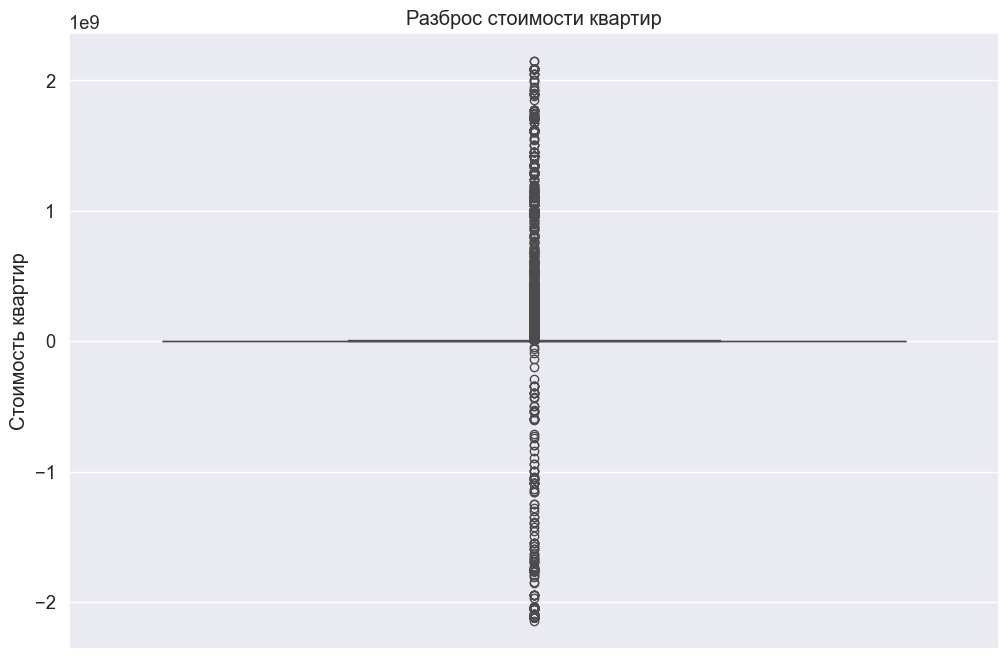

In [35]:
# строим диаграмму размаха
sns.boxplot(data['price']).set(title='Разброс стоимости квартир',ylabel='Стоимость квартир')

In [36]:
# статистика
data['price'].describe()

count       5241351.00
mean        4505811.64
std        20232382.73
min     -2144967296.00
25%         2000000.00
50%         3050000.00
75%         4940000.00
max      2147483647.00
Name: price, dtype: float64

In [37]:
# ищем кол-во строк, в которых цена меньше или равна нуля
q3 = data.query('price<=0')['price'].count()
q3

np.int64(334)

In [38]:
data.query('price<=0')

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month
43821,-1633967296,2018-09-14,5520,1,13,22,1,38.92,NaN,11,Пермский край,2018,9
43822,-1633967296,2018-09-14,5520,1,14,22,1,38.92,17.26,11,Пермский край,2018,9
179212,0,2018-10-01,6817,3,5,10,3,104.00,15.00,1,Алтайский край,2018,10
199895,-429242296,2018-10-04,9654,2,5,25,2,57.27,9.31,11,Новосибирская область,2018,10
208483,-1744967296,2018-10-06,9654,3,4,5,2,45.00,6.00,1,Новосибирская область,2018,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5382188,-2041757296,2021-04-23,2604,3,2,4,1,41.08,9.31,11,Ярославская область,2021,4
5382595,-1794967296,2021-04-23,81,1,4,5,2,56.00,9.00,1,Московская область,2021,4
5398253,-1494967296,2021-04-26,2843,3,3,3,1,45.00,17.00,11,Краснодарский край,2021,4
5419426,-2094967296,2021-04-27,3991,3,14,19,1,30.00,8.00,1,Тюменская область,2021,4


In [39]:
# оставляем только строки, в которых цена больше нуля
data = data.query('price>0').reset_index(drop=True)
data

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург,2018,2
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область,2018,2
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область,2018,2
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,11,Краснодарский край,2018,3
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область,2018,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5241012,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,11,Москва,2021,5
5241013,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,11,Москва,2021,5
5241014,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1,Нижегородская область,2021,5
5241015,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,11,Москва,2021,5


In [40]:
# ищем кол-во строк, в которых количество комнат равно "-2"
q4 = data.query('rooms==[-2]')['rooms'].count()
q4

np.int64(343)

In [41]:
data.query('rooms==[-2]').head(5)

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month
61890,24912000,2018-09-17,2843,2,22,22,-2,415.20,40.00,11,Краснодарский край,2018,9
87350,25500000,2018-09-18,2661,3,1,7,-2,360.00,22.00,1,Санкт-Петербург,2018,9
108575,3150000,2018-09-21,2661,2,2,17,-2,35.00,9.00,1,Санкт-Петербург,2018,9
114222,4300000,2018-09-22,81,3,3,5,-2,61.00,5.60,1,Московская область,2018,9
138059,57000000,2018-09-26,81,3,3,3,-2,300.00,30.00,1,Московская область,2018,9


In [42]:
# оставляем только строки, в которых количество комнат больше нуля или "-1"
data = data.query('rooms!=[-2]')
data

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург,2018,2
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область,2018,2
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область,2018,2
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,11,Краснодарский край,2018,3
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область,2018,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5241012,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,11,Москва,2021,5
5241013,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,11,Москва,2021,5
5241014,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1,Нижегородская область,2021,5
5241015,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,11,Москва,2021,5


[Text(0.5, 1.0, 'Разброс площади квартир'), Text(0, 0.5, 'Площадь квартир')]

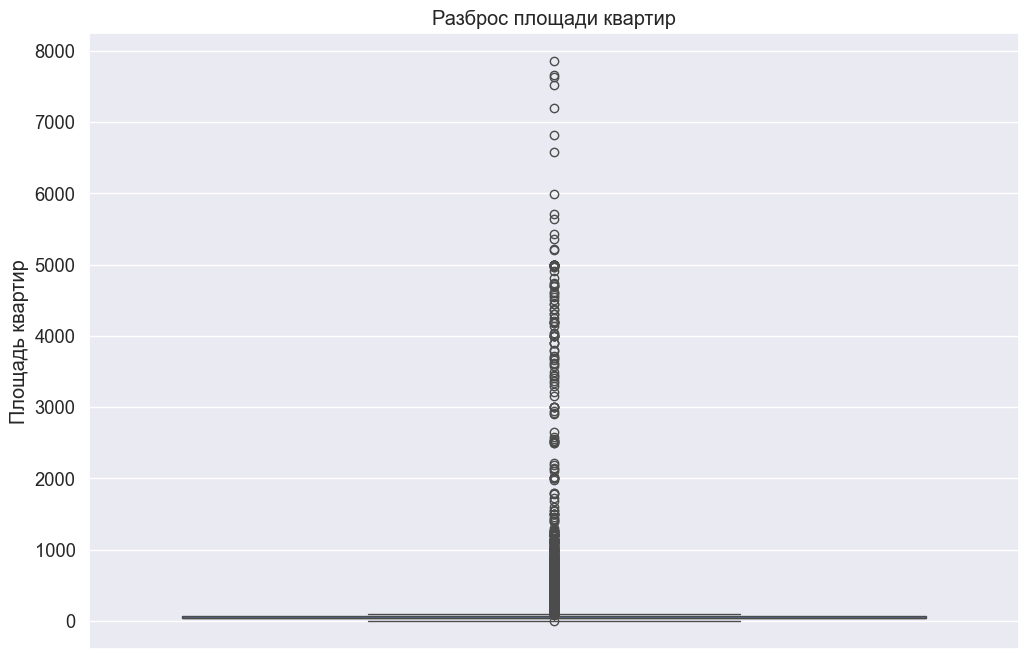

In [43]:
# строим диаграмму размаха
sns.boxplot(data['area']).set(title='Разброс площади квартир',ylabel='Площадь квартир')

In [44]:
# статистика
data['area'].describe()

count   5240674.00
mean         53.96
std          33.73
min           0.07
25%          38.00
50%          48.02
75%          63.20
max        7856.00
Name: area, dtype: float64

In [45]:
# ищем кол-во строк, в которых площадь квартиры меньше или равна нуля
q5 = data.query('kitchen_area<=0')['kitchen_area'].count()
q5

np.int64(0)

In [46]:
q5 = data.query('area<=0')['area'].count()
q5

np.int64(0)

In [47]:
# ищем кол-во строк, в которых этаж квартиры больше кол-ва этажей в здании
q6 = (data['level']>data['levels']).sum()
q6

np.int64(665)

In [48]:
data[data['level']>data['levels']].head(5)

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month
25926,1850000,2018-09-12,3870,3,17,13,1,37.00,10.00,1,Красноярский край,2018,9
35443,1100000,2018-09-13,9654,3,4,1,1,30.00,8.00,1,Новосибирская область,2018,9
114116,700000,2018-09-22,2722,3,2,1,2,40.00,11.00,1,Республика Башкортостан,2018,9
143678,3200000,2018-09-27,11171,2,4,3,1,31.00,10.00,1,Республика Саха (Якутия),2018,9
157468,1050000,2018-09-28,2843,4,2,1,2,54.00,10.00,1,Краснодарский край,2018,9


In [49]:
# оставляем только строки, в которых этаж квартиры больше или равен кол-ву этажей в здании
data = data[data['level']<=data['levels']]

In [50]:
data

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург,2018,2
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область,2018,2
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область,2018,2
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,11,Краснодарский край,2018,3
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область,2018,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5241012,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,11,Москва,2021,5
5241013,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,11,Москва,2021,5
5241014,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1,Нижегородская область,2021,5
5241015,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,11,Москва,2021,5


In [1]:
# создаем новый столбец с ценой за 1 квадартный метр площади квартиры 
data['price_1kv_m'] = round(data['price']/data['area'],4)
data

NameError: name 'data' is not defined

[Text(0.5, 1.0, 'Разброс средней цены за 1 квадратный метр жилья'),
 Text(0, 0.5, 'Средняя цена за 1 квадратный метр жилья')]

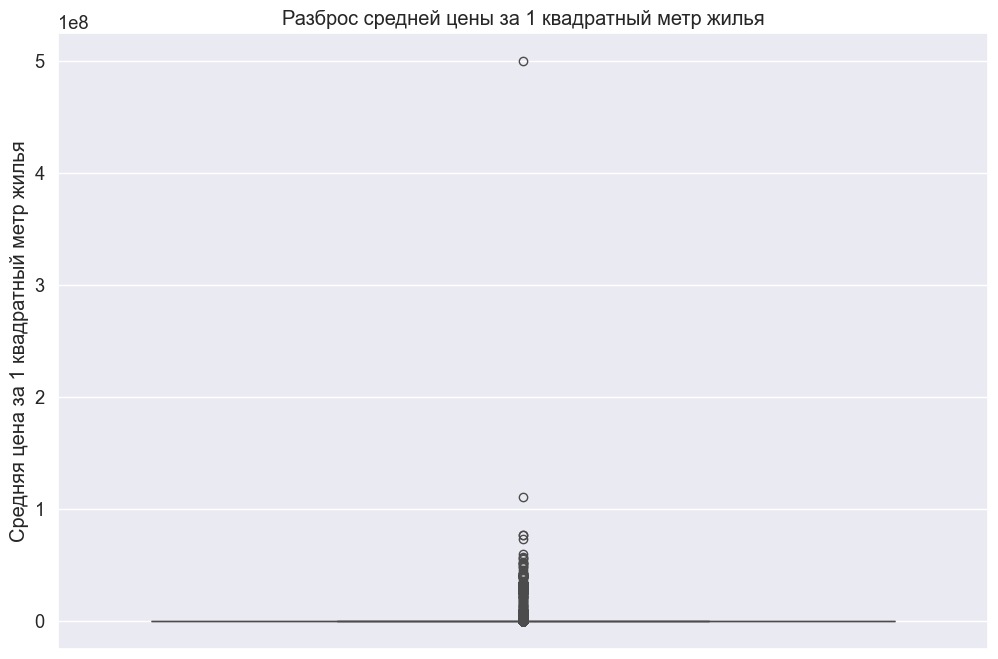

In [54]:
# строим диаграмму размаха
sns.boxplot(data['price_1kv_m']).set(title='Разброс средней цены за 1 квадратный метр жилья',ylabel='Средняя цена за 1 квадратный метр жилья')

In [55]:
# статистика
data['price_1kv_m'].describe()

count     5240009.00
mean        83075.38
std        381727.53
min             0.00
25%         44318.18
50%         62068.97
75%         93333.33
max     499999999.50
Name: price_1kv_m, dtype: float64

In [56]:
# выбросы
q99 = np.percentile(data['price_1kv_m'], 99)
q1 = np.percentile(data['price_1kv_m'], 1)
print("Нижняя граница:", q1)
print("Верхняя граница:", q99)
n_ejection = data['price_1kv_m'][(data['price_1kv_m'] > q99) | (data['price_1kv_m'] < q1)].count()
print('Число выбросов:', n_ejection)
q2 = (n_ejection/len(data['price_1kv_m'])*100).round(4)
print(q2,'%')

Нижняя граница: 17857.1429
Верхняя граница: 308862.42122
Число выбросов: 104667
1.9975 %


In [57]:
# выбросы
q75 = np.percentile(data['price_1kv_m'], 75)
q25 = np.percentile(data['price_1kv_m'], 25)
iqr = np.percentile(data['price_1kv_m'],75) - np.percentile(data['price_1kv_m'],25)
ejection_h = q75+1.5*iqr 
ejection_l = q25-1.5*iqr
print("Нижняя граница:", ejection_l)
print("Верхняя граница:", ejection_h)
n_ejection = data['price_1kv_m'][(data['price_1kv_m'] > ejection_h)].count()
print('Число выбросов:', n_ejection)
q2 = (n_ejection/len(data['price_1kv_m'])*100).round(4)
print(q2,'%')

Нижняя граница: -29204.545449999998
Верхняя граница: 166856.06055
Число выбросов: 398572
7.6063 %


In [58]:
# выбросы
def remove (group):
    q99 = np.percentile(group['price_1kv_m'], 99)
    q1 = np.percentile(group['price_1kv_m'], 1)
    return group[(group['price_1kv_m'] < q99)&(group['price_1kv_m'] > q1)]
data_n = data.groupby('reg_name', group_keys=False).apply(remove)
data_n = data_n.sort_index()
data_n = data_n.reset_index(drop=True)
p1 = len(data)-len(data_n)
print('Число выбросов:', p1)
print('Процент выбросов от всего датасета',p1/len(data)*100,'%')

/var/folders/cr/yh2kbzs57zx4zjm1mqpvnwd40000gn/T/ipykernel_61185/2047536994.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_n = data.groupby('reg_name', group_keys=False).apply(remove)


Число выбросов: 105142
Процент выбросов от всего датасета 2.006523271238656 %


In [59]:
# выбросы
def remove (group):
    q75 = np.percentile(group['price_1kv_m'], 75)
    q25 = np.percentile(group['price_1kv_m'], 25)
    iqr = q75 - q25
    ejection_l = q25 - 1.5 * iqr
    ejection_h = q75 + 1.5 * iqr
    return group[(group['price_1kv_m'] < ejection_h)&(group['price_1kv_m'] > ejection_l)]
data_n2 = data.groupby('reg_name', group_keys=False).apply(remove)
p2 = len(data)-len(data_n2)
print('Число выбросов:', p2)
print('Процент выбросов от всего датасета',p2/len(data)*100,'%')

Число выбросов: 168493
Процент выбросов от всего датасета 3.2155097443534926 %


/var/folders/cr/yh2kbzs57zx4zjm1mqpvnwd40000gn/T/ipykernel_61185/2170806509.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_n2 = data.groupby('reg_name', group_keys=False).apply(remove)


In [60]:
data_n

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month,price_1kv_m
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург,2018,2,73244.55
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область,2018,2,125180.90
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область,2018,2,60606.06
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,11,Краснодарский край,2018,3,48684.21
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область,2018,3,90833.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5134862,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,11,Москва,2021,5,211800.00
5134863,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,11,Москва,2021,5,272400.00
5134864,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1,Нижегородская область,2021,5,101734.10
5134865,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,11,Москва,2021,5,227100.00


[Text(0.5, 1.0, 'Разброс средней цены за 1 квадратный метр жилья'),
 Text(0, 0.5, 'Средняя цена за 1 квадратный метр жилья')]

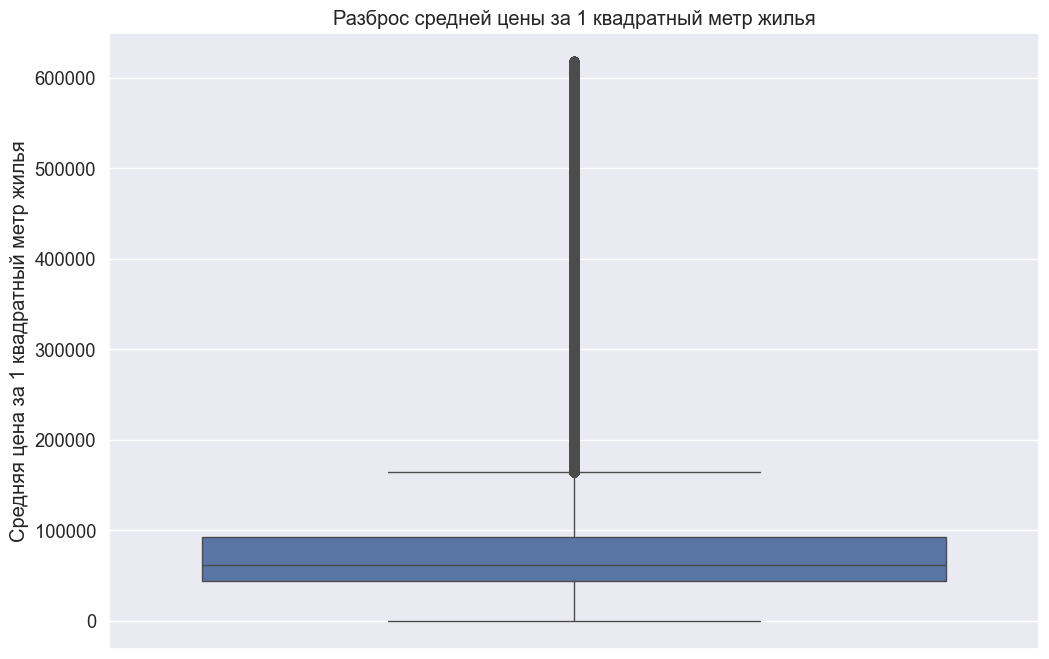

In [61]:
# строим диаграмму размаха
sns.boxplot(data_n['price_1kv_m']).set(title='Разброс средней цены за 1 квадратный метр жилья',ylabel='Средняя цена за 1 квадратный метр жилья')

In [62]:
# статистика
data_n['price_1kv_m'].describe()

count   5134867.00
mean      78543.43
std       54909.10
min          84.00
25%       44642.86
50%       62051.85
75%       92447.92
max      618340.55
Name: price_1kv_m, dtype: float64

Text(0, 0.5, 'Плотность распределения')

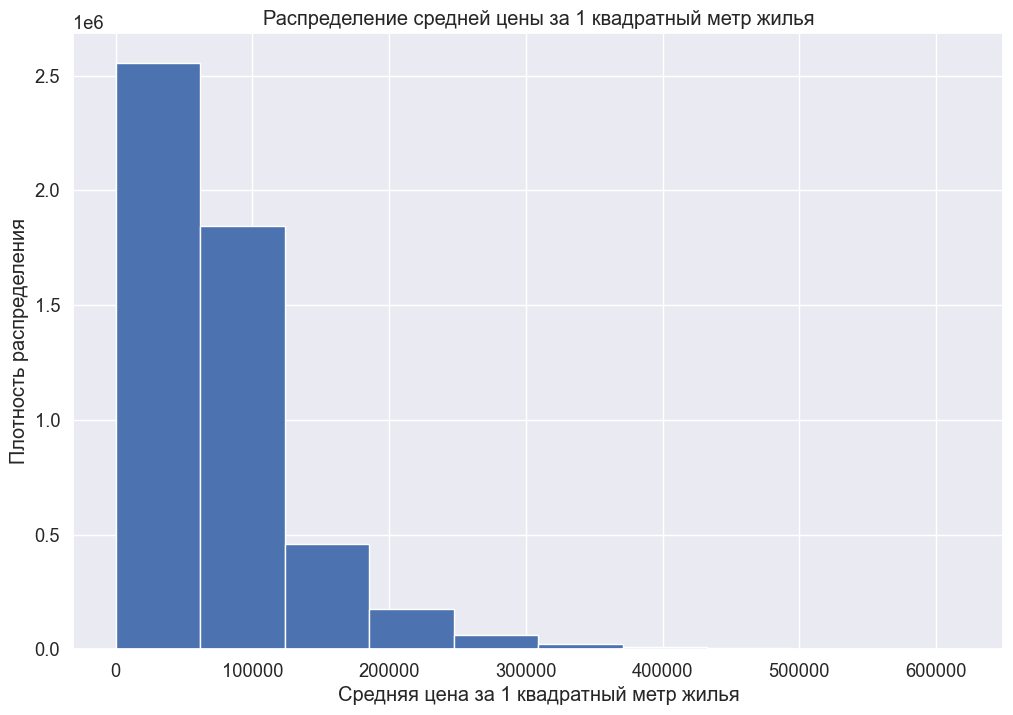

In [63]:
plt.hist(data_n['price_1kv_m'])
plt.title('Распределение средней цены за 1 квадратный метр жилья')
plt.xlabel('Средняя цена за 1 квадратный метр жилья')
plt.ylabel('Плотность распределения')

### Задание №3. Восстановление пропусков в столбце kitchen_area.

In [2]:
# выводим пропуски в столбце 'kitchen_area'
data[data['kitchen_area'].isna()]

NameError: name 'data' is not defined

In [65]:
# cтатистика до обработки пропусков
data_n['kitchen_area'].describe()

count   4887342.00
mean         10.62
std           9.13
min           0.01
25%           7.00
50%           9.70
75%          12.50
max        9999.00
Name: kitchen_area, dtype: float64

In [66]:
# делаем замену в данных, чтобы найти корреляцию
data_n.loc[data_n['object_type'] == 11, 'object_type'] = 0
data_n['object_type'].unique()

array([1, 0])

In [67]:
data_n['nazv_gr_area'] = pd.cut(data_n['area'], bins=[-1,38,48,63,10000], labels=['1', '2', '3', '4'])

In [68]:
data_known = data_n[data_n['kitchen_area'].notna()]
data_n.loc[data_known.index, 'kitchen_dolya'] = data_known['kitchen_area']/data_known['area']
group = data_n.groupby(['rooms','building_type','object_type', 'nazv_gr_area'])['kitchen_dolya'].quantile(0.5)
data_n['kitchen_dolya_gr'] = data_n.set_index(['rooms','building_type','object_type','nazv_gr_area']).index.map(group)
data_n

/var/folders/cr/yh2kbzs57zx4zjm1mqpvnwd40000gn/T/ipykernel_61185/4201936957.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = data_n.groupby(['rooms','building_type','object_type', 'nazv_gr_area'])['kitchen_dolya'].quantile(0.5)


,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month,price_1kv_m,nazv_gr_area,kitchen_dolya,kitchen_dolya_gr
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург,2018,2,73244.55,4,0.13,0.14
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область,2018,2,125180.90,4,0.17,0.19
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область,2018,2,60606.06,4,0.15,0.14
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,0,Краснодарский край,2018,3,48684.21,1,0.13,0.16
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область,2018,3,90833.33,3,0.17,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5134862,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,0,Москва,2021,5,211800.00,4,0.15,0.15
5134863,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,0,Москва,2021,5,272400.00,2,0.14,0.21
5134864,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1,Нижегородская область,2021,5,101734.10,4,0.14,0.16
5134865,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,0,Москва,2021,5,227100.00,3,0.36,0.19


In [69]:
prop = data_n['kitchen_area'].isna()
data_n.loc[prop, 'kitchen_area'] = data_n.loc[prop, 'area']*data_n.loc[prop, 'kitchen_dolya_gr']

In [70]:
data_n.drop(columns=['kitchen_dolya', 'kitchen_dolya_gr'], inplace=True)

In [71]:
data_n.drop(columns=['nazv_gr_area'], inplace=True)

In [72]:
data_n['kitchen_area'].describe()

count   5134867.00
mean         10.58
std           8.94
min           0.01
25%           7.00
50%           9.70
75%          12.50
max        9999.00
Name: kitchen_area, dtype: float64

#### Вывод по пункту №3:
1. В столбце "kitchen_area" датасета было найдено 252613 пропусков, которые нужно заполнить;
2. Изначально была и реализована идея заполнить эти пропуски при помощи модели линейной регрессии. Однако, расчет R^2 построенной модели показал 0,177. То есть, вариация площади кухни на 17,7% объясняется представленных в моедли факторов. Этот показатель оказался очень низким, поэтому идея заполнения пропусков при помощи модели линейной регрессии была отвергнута;
3. Поэтому мы решили заполнить пропуски в столбце таким способом: разделить весь датасет на группы по опредленным признакам и в каждом рассчитать долю от общей площади квартиры по 0.5 квантилю. Тем самым, такой подход позволяет учесть структурные особенности данных — различия по числу комнат, типу дома, типу рынка и другим характеристикам. В результате заполненные значения получаются более реалистичными по сравнению с использованием среднего или глобальной медианы и позволяют избежать существенных искажений распределения признака;
4. Проверка основных статистических показателей до и после обработки пропусков показала, что с большей вероятностью пропуски были заполнены правильно. Так, среднее значение площади кухни изменилось незначительно, стандартное отклонение увеличилось на , а медиана, min, max, q25, q75 почти не отличаются от этих же показателей до обработки пропусков. 

In [78]:
# меняем типы данных
data_n['building_type'] = data_n['building_type'].astype('str')
data_n['rooms'] = data_n['rooms'].astype('str')
data_n['levels'] = data_n['levels'].astype('str')
data_n['level'] = data_n['level'].astype('str')
data_n['object_type'] = data_n['object_type'].astype('str')

/var/folders/cr/yh2kbzs57zx4zjm1mqpvnwd40000gn/T/ipykernel_61185/2230199873.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_n['building_type'] = data_n['building_type'].astype('str')
/var/folders/cr/yh2kbzs57zx4zjm1mqpvnwd40000gn/T/ipykernel_61185/2230199873.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_n['rooms'] = data_n['rooms'].astype('str')
/var/folders/cr/yh2kbzs57zx4zjm1mqpvnwd40000gn/T/ipykernel_61185/2230199873.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [79]:
data_n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5133951 entries, 0 to 5134866
Data columns (total 14 columns):
 #   Column         Dtype         
---  ------         -----         
 0   price          int64         
 1   date           datetime64[ns]
 2   region         object        
 3   building_type  object        
 4   level          object        
 5   levels         object        
 6   rooms          object        
 7   area           float64       
 8   kitchen_area   float64       
 9   object_type    object        
 10  reg_name       object        
 11  year           int32         
 12  month          int32         
 13  price_1kv_m    float64       
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(7)
memory usage: 548.4+ MB


In [80]:
# ищем кол-во строк, в которых площадь кухни больше или равна площади квартиры
q7 = data_n[data_n['kitchen_area']>data_n['area']]['area'].count()
q7

np.int64(0)

In [81]:
data_n[data_n['kitchen_area']>data_n['area']].head(5)

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month,price_1kv_m


In [82]:
# оставляем только строки, в которых площадь кухни меньше или равна площади квартиры
data_n = data_n[data_n['kitchen_area']<=data_n['area']]

In [83]:
data_n.head(5)

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month,price_1kv_m
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург,2018,2,73244.55
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область,2018,2,125180.90
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область,2018,2,60606.06
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,0,Краснодарский край,2018,3,48684.21
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область,2018,3,90833.33


In [84]:
data_n['kitchen_area'].describe()

count   5133951.00
mean         10.56
std           5.34
min           0.01
25%           7.00
50%           9.70
75%          12.49
max         300.00
Name: kitchen_area, dtype: float64

In [85]:
data_n['area'].describe()

count   5133951.00
mean         53.43
std          24.18
min           1.00
25%          38.00
50%          48.00
75%          63.00
max        5220.00
Name: area, dtype: float64

In [86]:
data_n['price'].describe()

count     5133951.00
mean      4313834.88
std       4852549.30
min          1350.00
25%       2000000.00
50%       3050000.00
75%       4900000.00
max     395000000.00
Name: price, dtype: float64

In [87]:
data_n['price_1kv_m'].describe()

count   5133951.00
mean      78545.04
std       54907.54
min          84.00
25%       44642.86
50%       62054.79
75%       92447.92
max      618340.55
Name: price_1kv_m, dtype: float64

In [88]:
data_n.query('kitchen_area==0.01')

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month,price_1kv_m
992034,1180000,2019-02-05,9654,3,3,3,1,23.60,0.01,0,Новосибирская область,2019,2,50000.00
992280,1012500,2019-02-05,9654,3,3,3,1,20.25,0.01,0,Новосибирская область,2019,2,50000.00
1131688,1470000,2019-02-26,6171,4,4,5,1,25.00,0.01,1,Свердловская область,2019,2,58800.00
1158145,1380000,2019-02-28,9654,3,3,3,-1,27.60,0.01,0,Новосибирская область,2019,2,50000.00
1158630,850500,2019-02-28,9654,3,3,3,-1,18.90,0.01,0,Новосибирская область,2019,2,45000.00
1158664,1180000,2019-02-28,9654,3,3,3,-1,23.60,0.01,0,Новосибирская область,2019,2,50000.00
1173485,5490000,2019-03-01,9654,3,3,10,3,73.40,0.01,1,Новосибирская область,2019,3,74795.64
1744370,2280000,2019-06-01,6171,2,4,5,1,23.00,0.01,0,Свердловская область,2019,6,99130.43
2091455,5350000,2019-07-31,9654,3,3,10,3,73.40,0.01,1,Новосибирская область,2019,7,72888.28
2253038,1990000,2019-09-02,6171,4,2,3,2,41.00,0.01,0,Свердловская область,2019,9,48536.59


#### Вывод по пункту №1:
#### Вывод по предобработке данных: 
1. В первую очередь была импортирована библиотка pandas, с помощью которой в дальнейшем мы сможем выполнить анализ и предобработку представленных данных. В дальнейшем при помощи функции 'pd.read_excel' был прочитан наш файл, а также были выведены первые 5 строк датасета для ознакомления.
2.  При помощи функции 'columns' были выведены все заголовки столбцов. Можно увидеть, что  все заголовки одного формата:на английском языке, с пониженным регистром и при необходимости с разделителем "_".
3.  C помощью функции 'pd.to_datetime()' мы преобразовали столбец "date" в столбец формата даты и времени (datetime), что позволяет в дальнейшем проводить временной анализ, сортировать и фильтровать данные по времени. На основе столбца 'date' были созданы новые столбцы "year" и "month", в которых соотвественно указаны отдельно года и месяца.
4. При помощи функции 'info', примененных ко всему датасету, были получены данные о количестве данных, их типе, пропусках в данных, которые помогут нам в дальнейшем в предобработке данных.
5. В датасете оказалось 252613 пропусков в столбце 'kitchen_area', которые в последующем были обработаны.
6. Также датасет был проверен на наличие явных и неявных дубликатов. С помощью функции "duplicated" была осуществлена проверка явных дубликатов, которых по итогу анализа в датасете оказалось 235655. По итогу явные дубликаты были удалены из датсета. При помощи функции "unique", которая выводит уникальные значения каждого столбца, были проверены неявные дубликаты, которых в датасете не оказалось
7. Кроме того, был проведен анализ аномалий в датасете. Он показал, что в датасете есть есть строки (334), в которых цена квартиры меньше или равна нулю. При помощи функции "query" в датасете были оставлены только те строки, в которых стоимость квартиры больше нулю.
8. Кроме того, в датасете были найдены строки (665), в которых этаж квартиры оказался больше, чем общее количество этажей в доме. Также при помощи функции "query" в датасете были оставлены только те строки, в которых этаж квартиры меньше или равен общему количеству этажей в доме.
9. Кроме того, в датасете оказались строки (343), в которых количество комнат равно -2. В исходных условиях о таких квартирах ничего не было сказано, поэтому было принято решение удалить такие строки.
10. Кроме того, анализ аномалий показал наличие строк (916), в которых площадь квартиры оказалось меньше площади квартиры. Такие строки в датасете были удалены.
11. Во всех случаях с аномальными значениями было принято решение удалить соответствующие строки, так как корректно исправить такие данные без дополнительной информации невозможно. Неизвестно, являются ли выявленные аномалии ошибками ввода или реальными, но редкими случаями. Поэтому их исправление могло бы привести к искажению данных и снижению качества дальнейшего анализа.
12. Однако после удаления явных анаомалий в датасете остались достаточно неявные. Например, в некоторых случаях квартира могла стоить меньше 10 рублей или больше нескольких миллиардов рублей, или площадь квартиры могла оказаться неприлично большой. Удаление выбросов по каждому из этих столбцов может привести к удалению важных значений данных, ведь, например, высокая стоимсоть квартиры может быть связана с большей площадью жилья или с регионом, в котором цена на квартиры выше, чем в других. Поэтому было принято решение по показателю цены за один квадратный метр в разрезе регионов, что позволяет учитывать региональные особенности рынка недвижимости и снижает риск исключения экономически обоснованных значений. Удаление выбросов было выполнено по 1-му и 99-му перцентилям показателя цены за один квадратный метр. Использование межквартильного размаха в данном случае оказалось менее подходящим, так как данный метод приводил к отсечению слишком большого количества наблюдений (>7.5% или 3.5% от всего датасета в зависимости от того, учитывались ли регионы в анализе) и, как следствие, повышал риск потери значимой информации. Выбор перцентильного подхода позволил удалить лишь крайние, наименее вероятные значения, сохранив при этом основную структуру и информативность данных. Тем самым, при помощи этого способа было удалено 105142 выбросов, что составляет 2% от всего датасета.
13. Также был изменен тип данных у некоторых столбцов, чтобы избежать ошибок при выполнении математических операций, упростить работу с данными и повысить общее качество датасета.
14. Как итог, после всей предобработки количество данных сократилось на 343 055 строк (6,26% от изначального датасета).

### Пункт №4. Исследование рынка недвижимости в РФ за представленный период.

In [89]:
data_n['date_year_month'] = data_n['date'].dt.to_period('M').astype(str)

In [90]:
data_n

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,reg_name,year,month,price_1kv_m,date_year_month
0,6050000,2018-02-19,2661,1,8,10,3,82.60,10.80,1,Санкт-Петербург,2018,2,73244.55,2018-02
1,8650000,2018-02-27,81,3,5,24,2,69.10,12.00,1,Московская область,2018,2,125180.90,2018-02
2,4000000,2018-02-28,2871,1,5,9,3,66.00,10.00,1,Нижегородская область,2018,2,60606.06,2018-02
3,1850000,2018-03-01,2843,4,12,16,2,38.00,5.00,0,Краснодарский край,2018,3,48684.21,2018-03
4,5450000,2018-03-01,81,3,13,14,2,60.00,10.00,1,Московская область,2018,3,90833.33,2018-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5134862,19739760,2021-05-01,3,1,8,17,4,93.20,13.80,0,Москва,2021,5,211800.00,2021-05
5134863,12503160,2021-05-01,3,2,17,32,2,45.90,6.60,0,Москва,2021,5,272400.00,2021-05
5134864,8800000,2021-05-01,2871,2,4,17,3,86.50,11.80,1,Нижегородская область,2021,5,101734.10,2021-05
5134865,11831910,2021-05-01,3,1,8,33,2,52.10,18.90,0,Москва,2021,5,227100.00,2021-05


In [91]:
rep1 = data_n.pivot_table(index='date_year_month', aggfunc='mean', values='price_1kv_m').reset_index()
rep1

,date_year_month,price_1kv_m
0,2018-02,86343.84
1,2018-03,79668.59
2,2018-04,82785.19
3,2018-05,73509.06
4,2018-06,69028.92
5,2018-07,61932.54
6,2018-08,73922.80
7,2018-09,68880.90
8,2018-10,66881.79
9,2018-11,66240.08


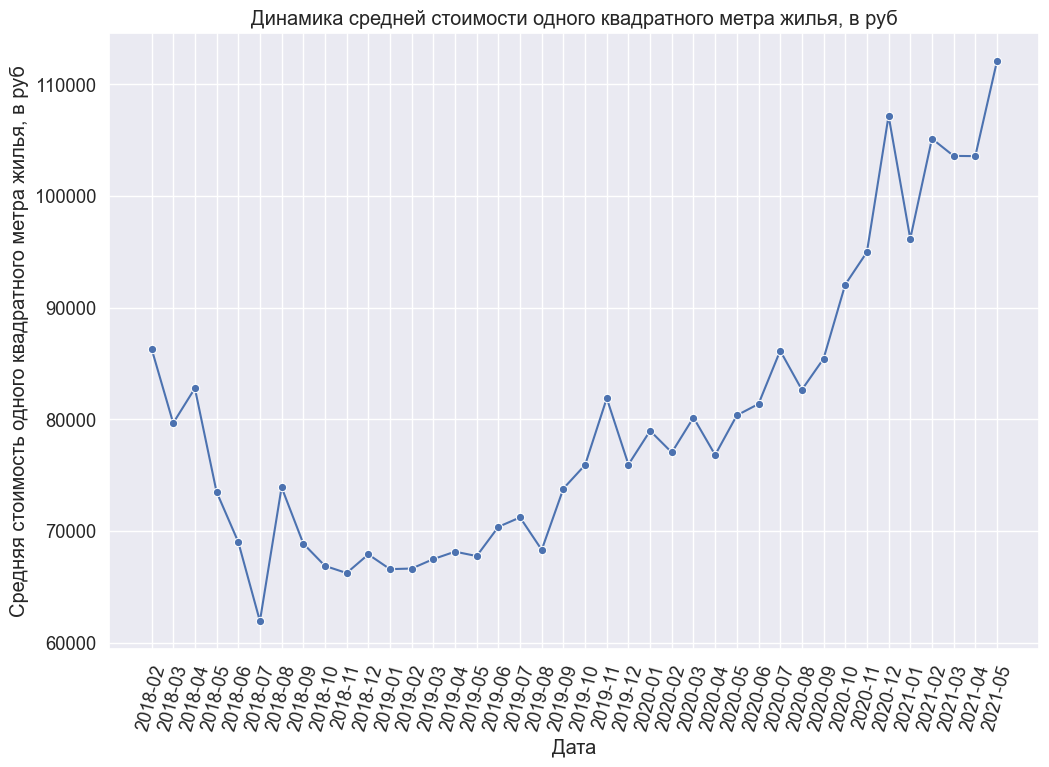

In [92]:
sns.lineplot(rep1, x='date_year_month', y='price_1kv_m',  marker='o',).set(xlabel='Дата', ylabel='Средняя стоимость одного квадратного метра жилья, в руб',title='Динамика средней стоимости одного квадратного метра жилья, в руб')
plt.xticks(rotation=75) 
plt.show()

In [93]:
rep2 = data_n.pivot_table(index='date_year_month', columns='building_type', aggfunc='mean', values='price_1kv_m').reset_index()
rep2 = rep2.fillna(0)
rep2

building_type,date_year_month,0,1,2,3,4,5
0,2018-02,0.00,66925.31,0.00,125180.90,0.00,0.00
1,2018-03,0.00,88847.67,81338.53,61497.76,48684.21,0.00
2,2018-04,0.00,96647.88,139168.71,64485.52,47844.20,0.00
3,2018-05,0.00,64498.10,53409.09,82727.82,0.00,0.00
4,2018-06,0.00,86427.41,81876.32,60253.93,70103.09,21698.11
5,2018-07,0.00,61335.66,96615.75,55725.99,63192.54,0.00
6,2018-08,0.00,83641.06,85450.58,63151.99,56647.19,0.00
7,2018-09,92506.67,56518.67,92527.82,62442.07,61429.84,71425.20
8,2018-10,62654.83,57178.83,93612.63,63698.10,60905.61,85449.53
9,2018-11,62971.31,56678.35,94223.34,62559.79,59935.51,32108.09


,building_type,price_1kv_m
0,Другое,80547.60
1,Панельный,67289.10
2,Кирпично-монолитный,112216.25
3,Кирпичный,69910.62
4,Блочный,69761.09
5,Деревянный,42405.31


[Text(0.5, 0, 'Средняя стоимость одного квадратного метра жилья, в руб'),
 Text(0, 0.5, 'Тип дома'),
 Text(0.5, 1.0, 'Cредняя стоимость одного квадратного метра жилья в зависимости от типа дома, в руб')]

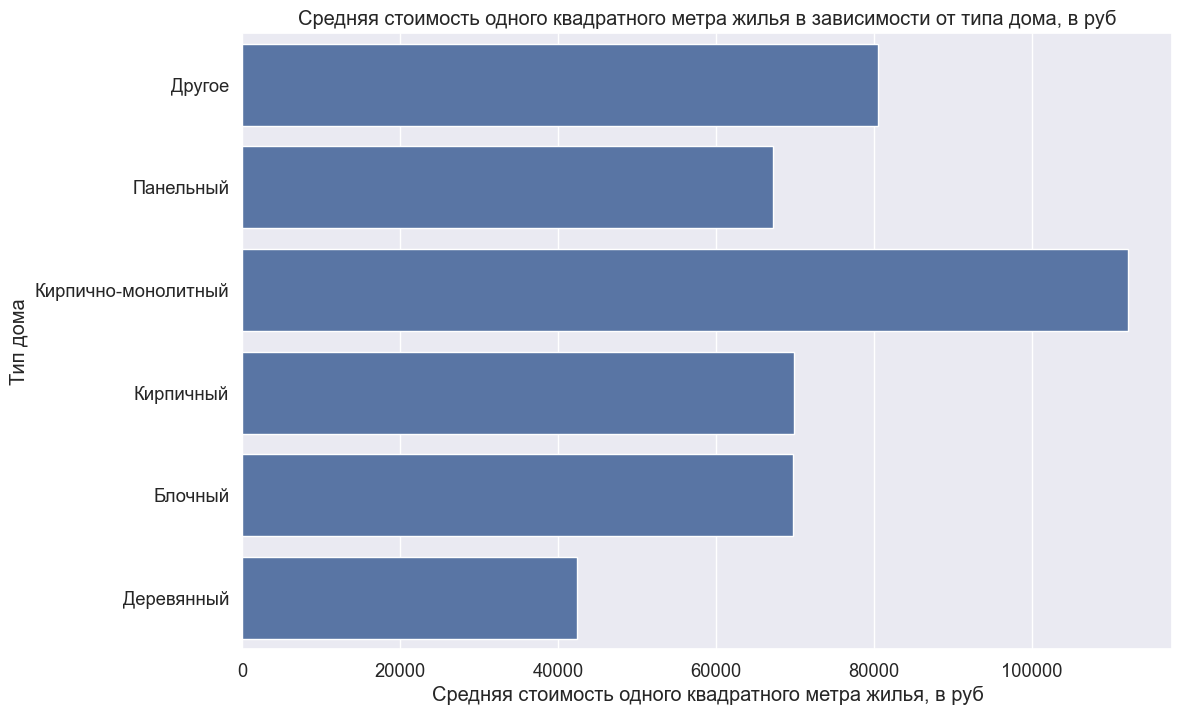

In [94]:
per1 = data_n.pivot_table(index='building_type', aggfunc='mean', values='price_1kv_m').reset_index()
m={'0' : 'Другое', '1' : 'Панельный', '2' : 'Кирпично-монолитный', '3' : 'Кирпичный', '4' : 'Блочный', '5' : 'Деревянный'}
per1['building_type']=per1['building_type'].map(m)
display(per1)
sns.barplot(per1, x='price_1kv_m', y='building_type', orient='h').set(xlabel='Средняя стоимость одного квадратного метра жилья, в руб', ylabel='Тип дома',title='Cредняя стоимость одного квадратного метра жилья в зависимости от типа дома, в руб')

object_type,building_type,0,1
0,Другое,80525.80,80567.11
1,Панельный,56637.28,70850.81
2,Кирпично-монолитный,119047.86,104776.16
3,Кирпичный,70865.54,69738.87
4,Блочный,53216.50,72192.21
5,Деревянный,74140.06,41727.65


<Axes: title={'center': 'Cредняя стоимость одного квадратного метра жилья в зависимости от типа дома и рынка, в руб'}, xlabel='Средняя стоимость одного квадратного метра жилья, в руб', ylabel='Тип дома'>

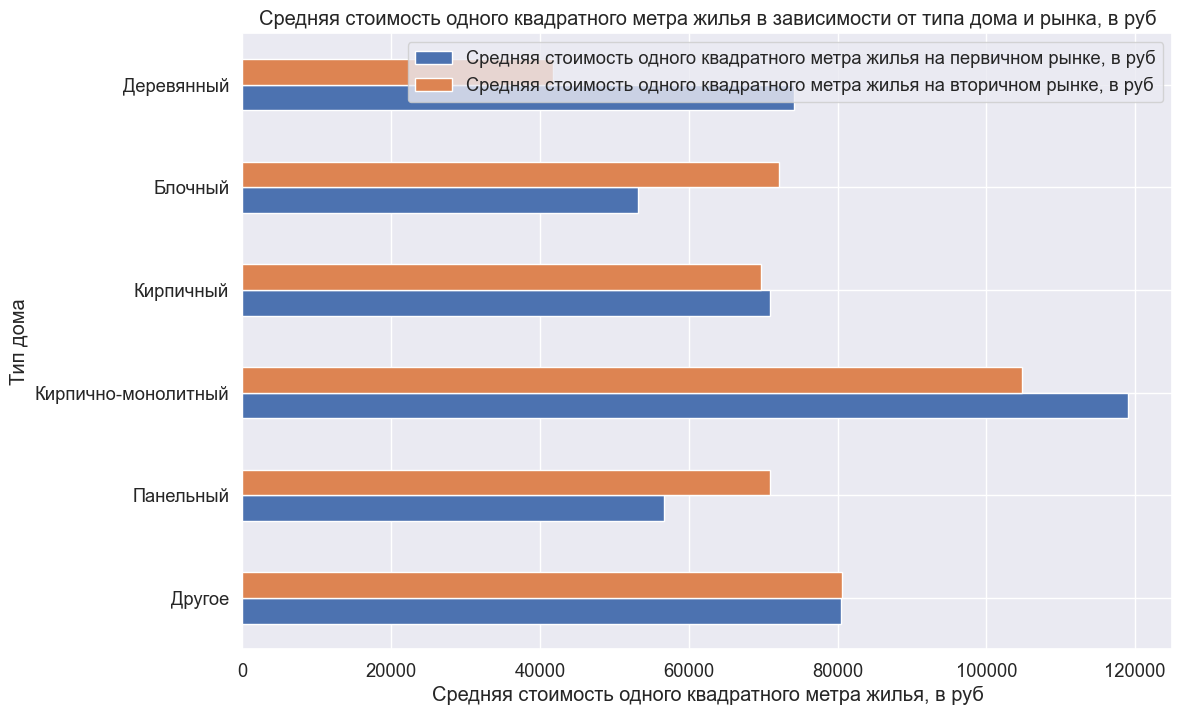

In [95]:
per1 = data_n.pivot_table(index='building_type', columns='object_type', aggfunc='mean', values='price_1kv_m').reset_index()
m={'0' : 'Другое', '1' : 'Панельный', '2' : 'Кирпично-монолитный', '3' : 'Кирпичный', '4' : 'Блочный', '5' : 'Деревянный'}
per1['building_type']=per1['building_type'].map(m)
display(per1)
# строим столбчатую диаграмму
per1.plot(kind='barh',x='building_type',y=['0','1'],label=['Средняя стоимость одного квадратного метра жилья на первичном рынке, в руб','Средняя стоимость одного квадратного метра жилья на вторичном рынке, в руб'],title='Cредняя стоимость одного квадратного метра жилья в зависимости от типа дома и рынка, в руб', xlabel='Средняя стоимость одного квадратного метра жилья, в руб',ylabel='Тип дома')

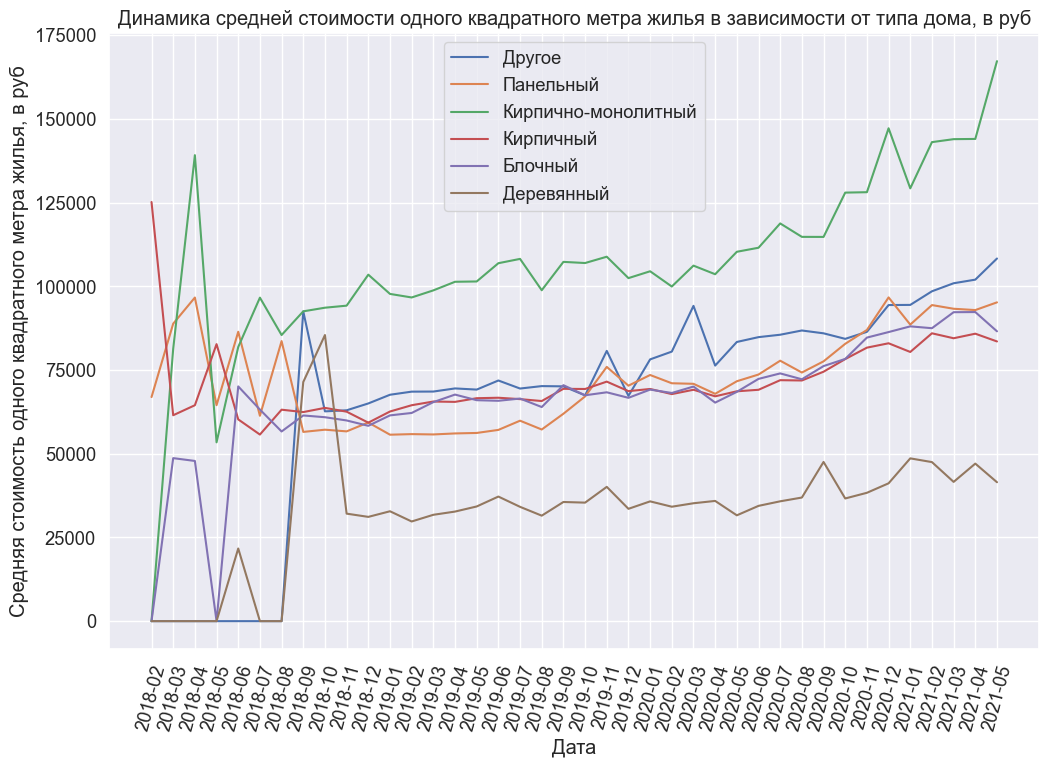

In [96]:
sns.lineplot(rep2, x='date_year_month', y='0', label='Другое')
(sns.lineplot(rep2, x='date_year_month', y='1', label='Панельный'))
(sns.lineplot(rep2, x='date_year_month', y='2', label='Кирпично-монолитный'))
(sns.lineplot(rep2, x='date_year_month', y='3', label='Кирпичный'))
(sns.lineplot(rep2, x='date_year_month', y='4', label='Блочный'))
(sns.lineplot(rep2, x='date_year_month', y='5', label='Деревянный')).set(xlabel='Дата', ylabel='Средняя стоимость одного квадратного метра жилья, в руб',title='Динамика средней стоимости одного квадратного метра жилья в зависимости от типа дома, в руб')
plt.xticks(rotation=75) 
plt.show()

,date_year_month,price_1kv_m
0,2018-02,66925.31
1,2018-03,88847.67
2,2018-04,96647.88
3,2018-05,64498.10
4,2018-06,86427.41
5,2018-07,61335.66
6,2018-08,83641.06
7,2018-09,56518.67
8,2018-10,57178.83
9,2018-11,56678.35


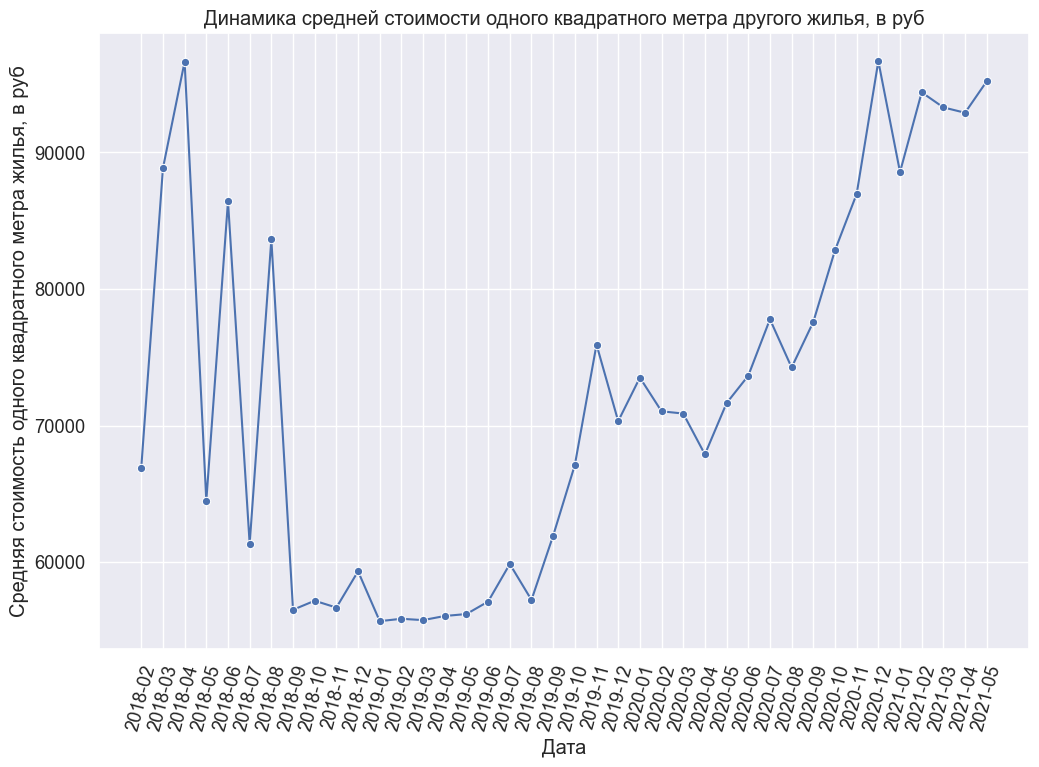

,date_year_month,price_1kv_m
0,2018-02,125180.90
1,2018-03,61497.76
2,2018-04,64485.52
3,2018-05,82727.82
4,2018-06,60253.93
5,2018-07,55725.99
6,2018-08,63151.99
7,2018-09,62442.07
8,2018-10,63698.10
9,2018-11,62559.79


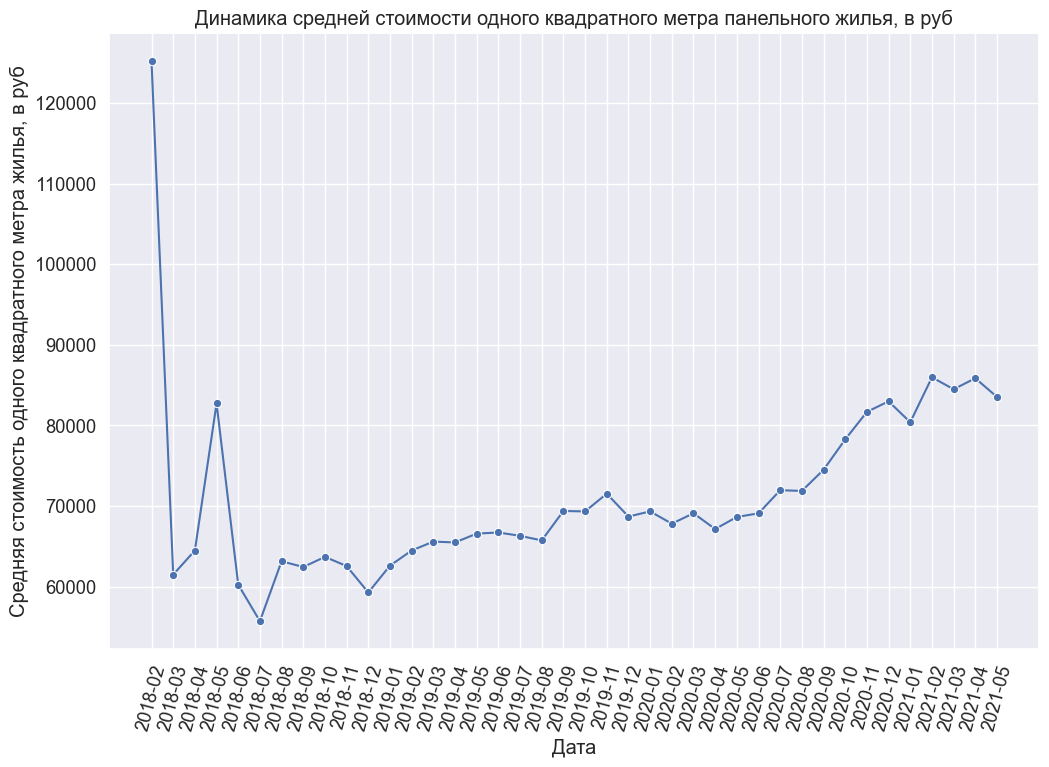

,date_year_month,price_1kv_m
0,2018-03,48684.21
1,2018-04,47844.20
2,2018-06,70103.09
3,2018-07,63192.54
4,2018-08,56647.19
5,2018-09,61429.84
6,2018-10,60905.61
7,2018-11,59935.51
8,2018-12,58341.50
9,2019-01,61453.94


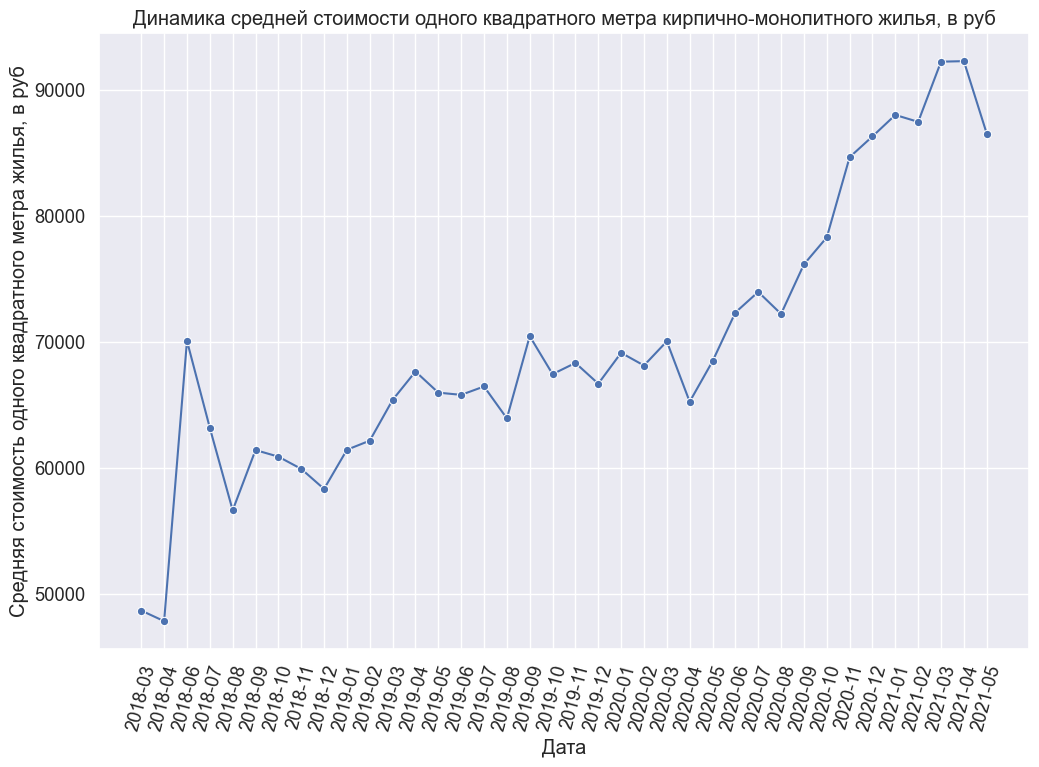

,date_year_month,price_1kv_m
0,2018-03,81338.53
1,2018-04,139168.71
2,2018-05,53409.09
3,2018-06,81876.32
4,2018-07,96615.75
5,2018-08,85450.58
6,2018-09,92527.82
7,2018-10,93612.63
8,2018-11,94223.34
9,2018-12,103479.89


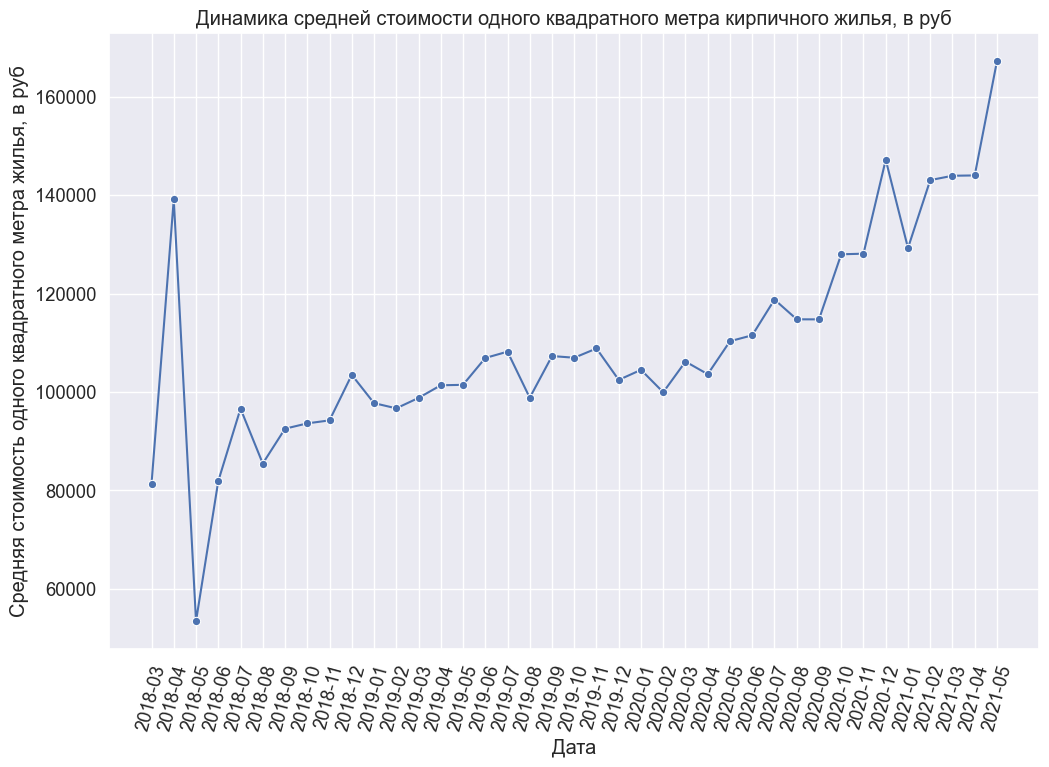

,date_year_month,price_1kv_m
0,2018-06,21698.11
1,2018-09,71425.20
2,2018-10,85449.53
3,2018-11,32108.09
4,2018-12,31141.44
5,2019-01,32817.10
6,2019-02,29766.41
7,2019-03,31761.22
8,2019-04,32725.33
9,2019-05,34250.80


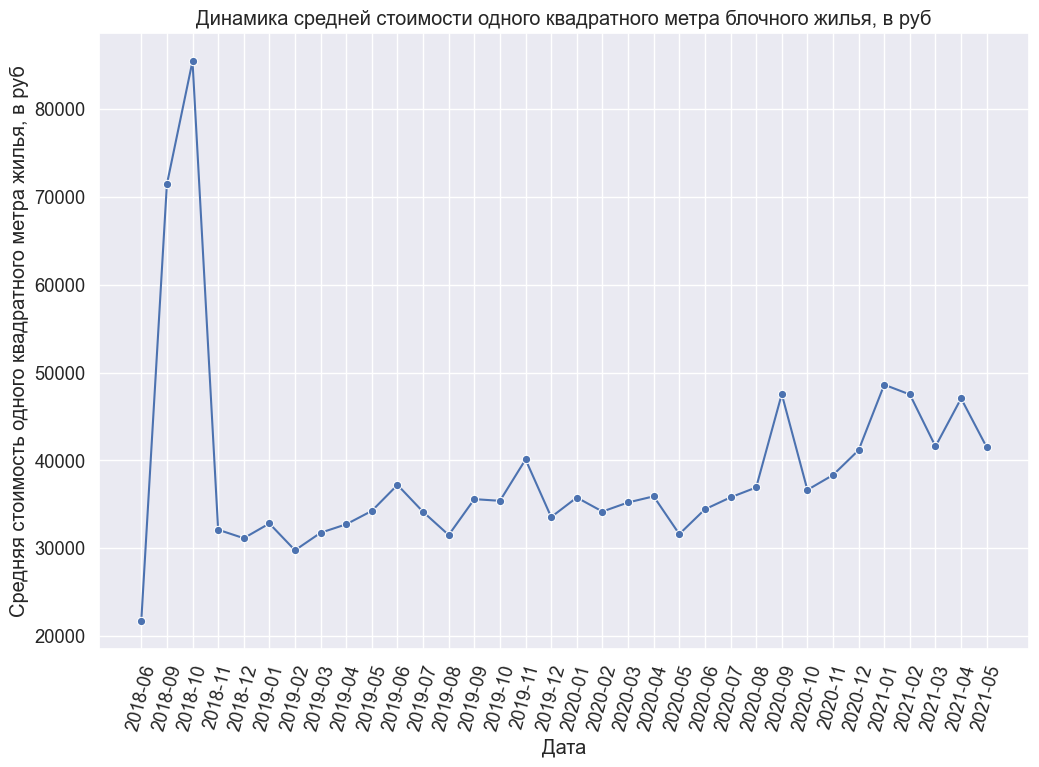

,date_year_month,price_1kv_m
0,2018-09,92506.67
1,2018-10,62654.83
2,2018-11,62971.31
3,2018-12,65017.86
4,2019-01,67615.80
5,2019-02,68543.21
6,2019-03,68570.04
7,2019-04,69503.71
8,2019-05,69157.22
9,2019-06,71871.55


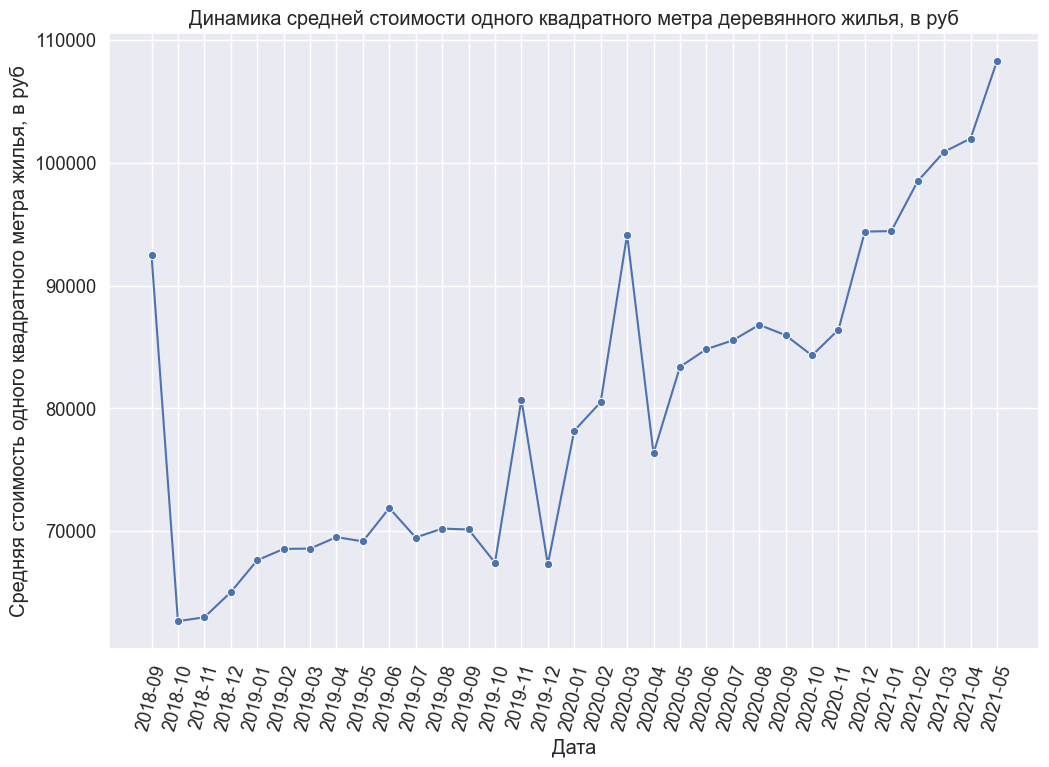

In [97]:
f2 = ['другого','панельного','кирпично-монолитного','кирпичного', 'блочного', 'деревянного']
f3=pd.DataFrame(index=data_n['building_type'].unique(),data=f2)
for n in data_n['building_type'].unique():
    rep3 = data_n.query('building_type==@n').pivot_table(index='date_year_month', aggfunc='mean', values='price_1kv_m').reset_index()
    rep3 = rep3.fillna(0)
    display(rep3)
    sns.lineplot(rep3, x='date_year_month', y='price_1kv_m', marker='o').set(xlabel='Дата', ylabel='Средняя стоимость одного квадратного метра жилья, в руб',title=f'Динамика средней стоимости одного квадратного метра {f3.loc[n][0]} жилья, в руб')
    plt.xticks(rotation=75) 
    plt.show()

In [98]:
rep4 = data_n.pivot_table(index='date_year_month', columns='object_type', aggfunc='mean', values='price_1kv_m').reset_index()
rep4 = rep4.fillna(0)
rep4['razn'] = rep4['0']-rep4['1']
rep4

object_type,date_year_month,0,1,razn
0,2018-02,0.00,86343.84,-86343.84
1,2018-03,84427.23,74513.40,9913.82
2,2018-04,55386.50,86073.03,-30686.52
3,2018-05,54105.11,75791.87,-21686.76
4,2018-06,63760.36,70692.68,-6932.32
5,2018-07,66437.72,61417.66,5020.06
6,2018-08,85331.30,69595.44,15735.86
7,2018-09,64463.89,70429.04,-5965.15
8,2018-10,66271.29,67123.68,-852.40
9,2018-11,65504.03,66531.36,-1027.32


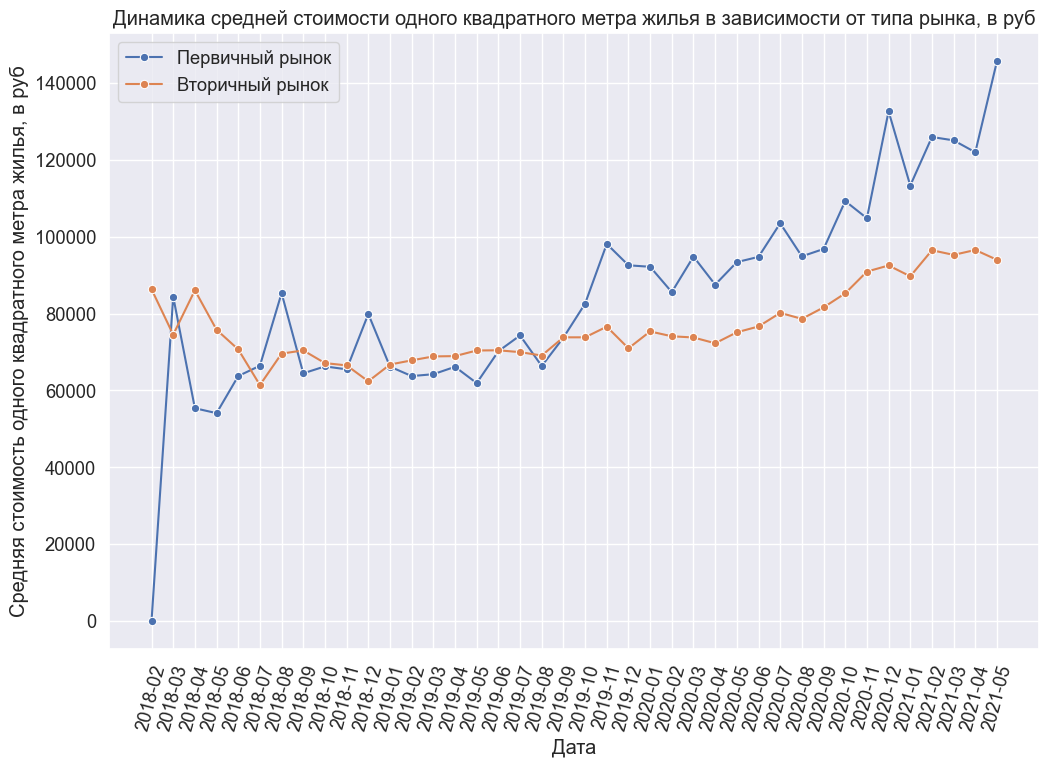

In [99]:
sns.lineplot(rep4, x='date_year_month', y='0', label='Первичный рынок',  marker='o')
(sns.lineplot(rep4, x='date_year_month', y='1', label='Вторичный рынок',  marker='o')).set(xlabel='Дата', ylabel='Средняя стоимость одного квадратного метра жилья, в руб',title='Динамика средней стоимости одного квадратного метра жилья в зависимости от типа рынка, в руб')
plt.xticks(rotation=75) 
plt.show()

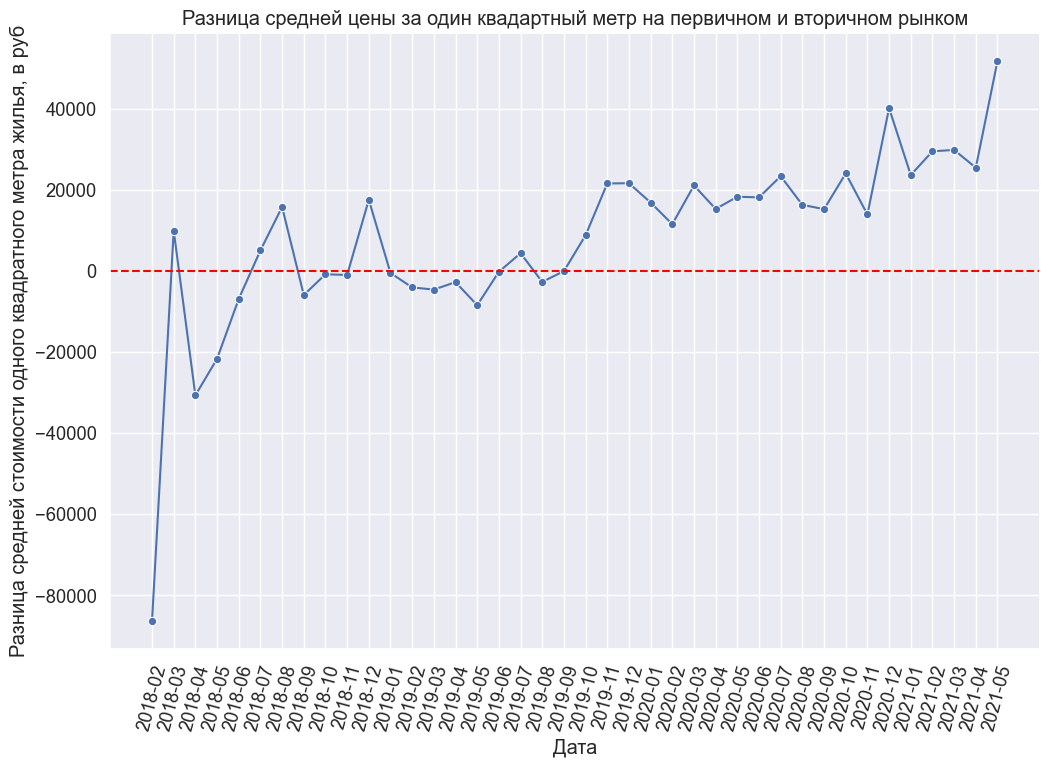

In [100]:
sns.lineplot(rep4, x='date_year_month', y='razn',  marker='o').set(xlabel='Дата', ylabel='Разница средней стоимости одного квадратного метра жилья, в руб',title='Разница средней цены за один квадартный метр на первичном и вторичном рынком')
plt.xticks(rotation=75) 
plt.axhline(y=0, color='red', linestyle='--') 
plt.show()

,reg_name,price_1kv_m
0,Москва,204804.38
1,Санкт-Петербург,130208.76
2,Московская область,92766.33
3,Республика Крым,87442.48
4,Амурская область,85130.92
5,Ленинградская область,83370.81
6,Ямало-Ненецкий автономный округ,73691.73
7,Архангельская область,72496.12
8,Хабаровский край,71648.53
9,Калининградская область,71085.87


[Text(0.5, 1.0, 'Топ-10 городов с наибольшей средней стоимостью квадратного метра жилья, в руб'),
 Text(0.5, 0, 'Средняя стоимость одного квадратного метра жилья, в руб'),
 Text(0, 0.5, 'Город')]

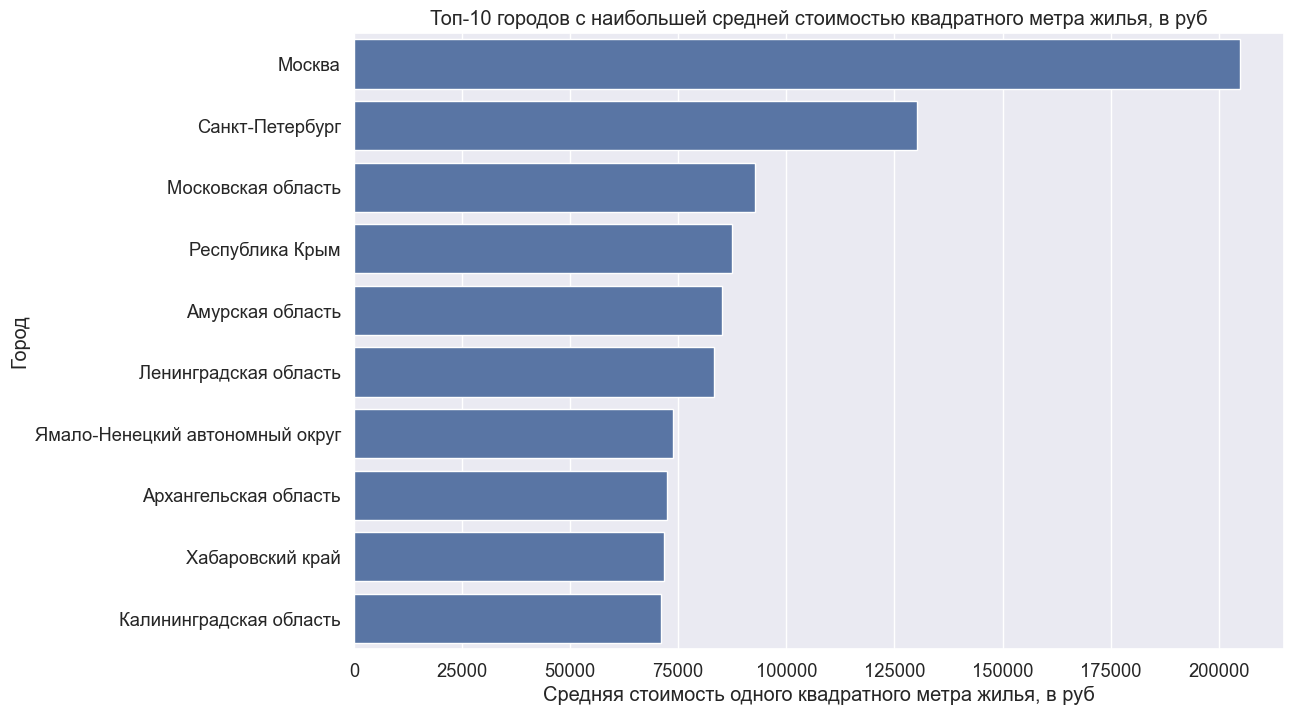

In [101]:
rep5 = data_n.pivot_table(index='reg_name', aggfunc='mean', values='price_1kv_m').sort_values(by='price_1kv_m', ascending=False).head(10).reset_index()
display(rep5)
sns.barplot(data=rep5,x='price_1kv_m',y='reg_name', orient='h').set(title='Топ-10 городов с наибольшей средней стоимостью квадратного метра жилья, в руб', xlabel='Средняя стоимость одного квадратного метра жилья, в руб',ylabel='Город')

,reg_name,price_1kv_m
0,Республика Ингушетия,29007.33
1,Республика Калмыкия,34912.12
2,Курганская область,36629.45
3,Псковская область,37703.21
4,Челябинская область,38064.00
5,Республика Марий Эл,38173.83
6,Кабардино-Балкарская Республика,39061.08
7,Саратовская область,40328.32
8,Кемеровская область,40638.26
9,Республика Северная Осетия — Алания,40660.60


[Text(0.5, 1.0, 'Топ-10 городов с наименьшей средней стоимостью квадратного метра жилья, в руб'),
 Text(0.5, 0, 'Средняя стоимость одного квадратного метра жилья, в руб'),
 Text(0, 0.5, 'Город')]

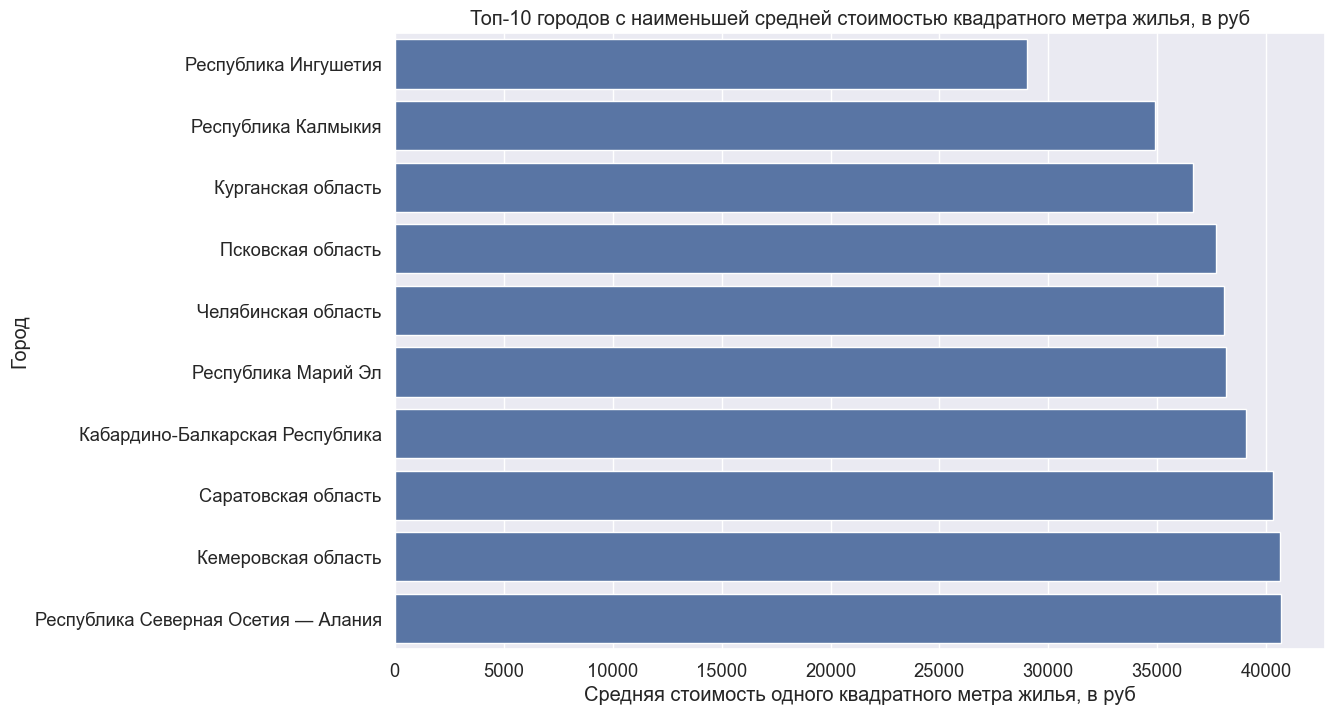

In [102]:
rep5 = data_n.pivot_table(index='reg_name', aggfunc='mean', values='price_1kv_m').sort_values(by='price_1kv_m', ascending=True).head(10).reset_index()
display(rep5)
sns.barplot(data=rep5,x='price_1kv_m',y='reg_name', orient='h').set(title='Топ-10 городов с наименьшей средней стоимостью квадратного метра жилья, в руб', xlabel='Средняя стоимость одного квадратного метра жилья, в руб',ylabel='Город')

object_type,reg_name,0,1
0,Москва,193229.58,213574.93
1,Санкт-Петербург,133422.31,127831.16
2,Московская область,106367.57,88402.43
3,Хабаровский край,95083.99,68966.74
4,Ленинградская область,89578.61,81256.41
5,Республика Крым,88000.00,87172.32
6,Амурская область,80165.64,85806.80
7,Архангельская область,79513.98,63308.95
8,Республика Саха (Якутия),78393.72,59462.23
9,Республика Татарстан,75766.14,67356.50


[Text(0.5, 1.0, 'Топ-10 городов с наибольшей средней стоимостью квадратного метра на первичном рынке жилья, в руб'),
 Text(0.5, 0, 'Средняя стоимость одного квадратного метра жилья, в руб'),
 Text(0, 0.5, 'Город')]

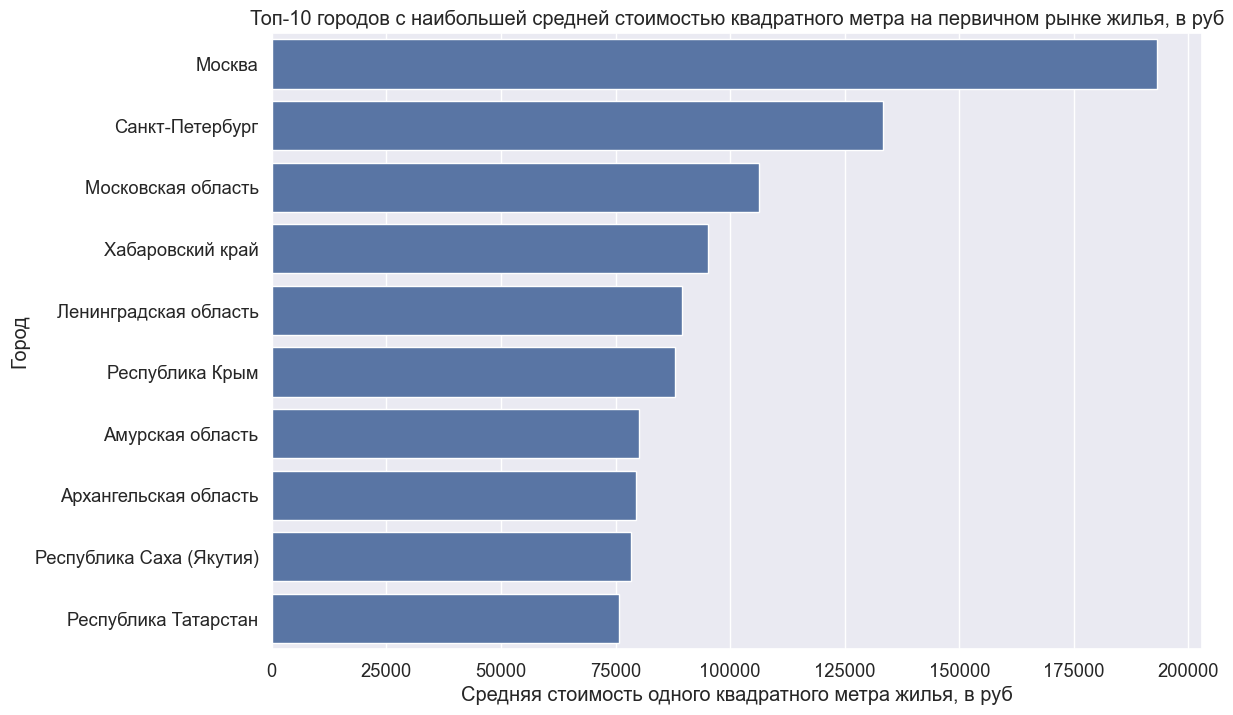

In [103]:
rep5 = data_n.pivot_table(index='reg_name', columns='object_type', aggfunc='mean', values='price_1kv_m').sort_values(by='0', ascending=False).head(10).reset_index()
display(rep5)
sns.barplot(data=rep5,x='0',y='reg_name', orient='h').set(title='Топ-10 городов с наибольшей средней стоимостью квадратного метра на первичном рынке жилья, в руб', xlabel='Средняя стоимость одного квадратного метра жилья, в руб',ylabel='Город')

object_type,reg_name,0,1
0,Москва,193229.58,213574.93
1,Санкт-Петербург,133422.31,127831.16
2,Московская область,106367.57,88402.43
3,Республика Крым,88000.00,87172.32
4,Амурская область,80165.64,85806.80
5,Ленинградская область,89578.61,81256.41
6,Калининградская область,65822.66,78645.80
7,Ямало-Ненецкий автономный округ,63743.32,73985.19
8,Ханты-Мансийский автономный округ,72828.00,70704.62
9,Хабаровский край,95083.99,68966.74


[Text(0.5, 1.0, 'Топ-10 городов с наибольшей средней стоимостью квадратного метра на вторичном рынке жилья, в руб'),
 Text(0.5, 0, 'Средняя стоимость одного квадратного метра жилья, в руб'),
 Text(0, 0.5, 'Город')]

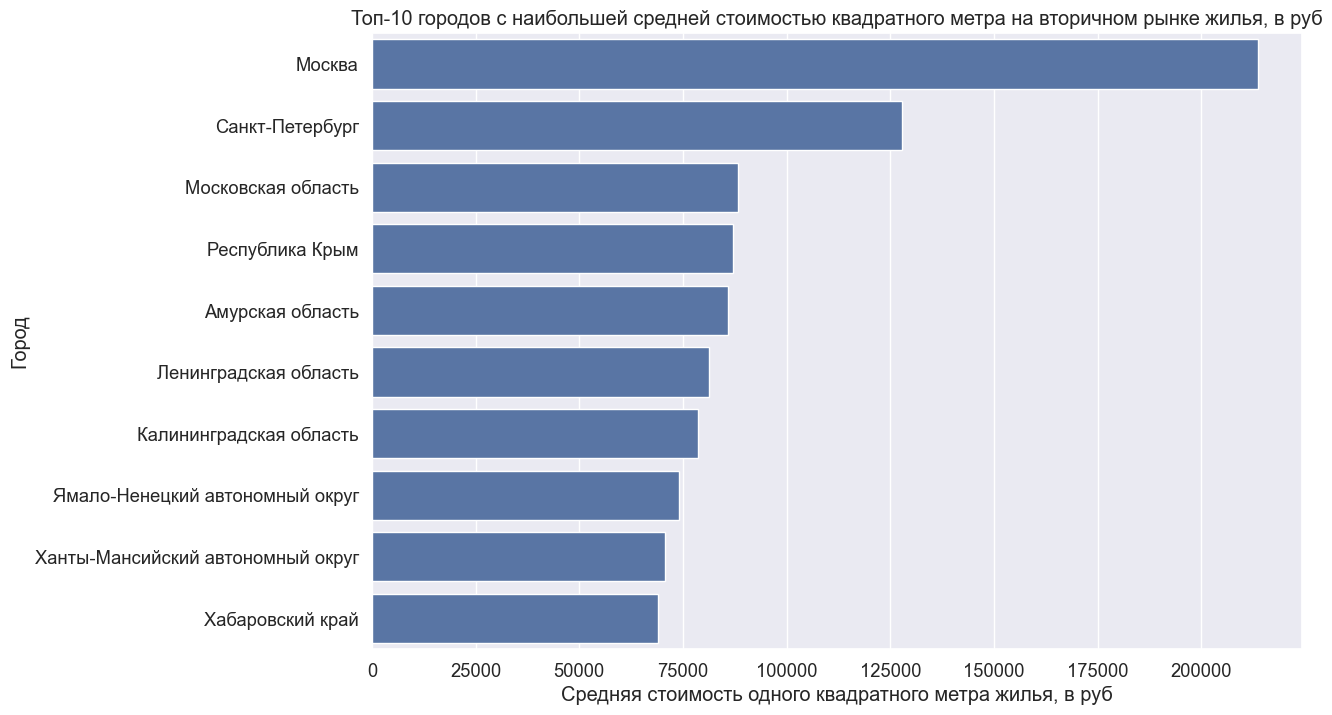

In [104]:
rep5 = data_n.pivot_table(index='reg_name', columns='object_type', aggfunc='mean', values='price_1kv_m').sort_values(by='1', ascending=False).head(10).reset_index()
display(rep5)
sns.barplot(data=rep5,x='1',y='reg_name', orient='h').set(title='Топ-10 городов с наибольшей средней стоимостью квадратного метра на вторичном рынке жилья, в руб', xlabel='Средняя стоимость одного квадратного метра жилья, в руб',ylabel='Город')

object_type,reg_name,0,1
0,Республика Ингушетия,26590.05,31404.46
1,Кабардино-Балкарская Республика,31860.11,41270.50
2,Республика Дагестан,33995.46,45145.98
3,Саратовская область,37383.95,43401.58
4,Республика Марий Эл,38036.17,38208.30
5,Республика Калмыкия,39174.57,34404.47
6,Курганская область,39205.78,36393.94
7,Псковская область,39809.46,36955.16
8,Республика Северная Осетия — Алания,40129.59,40837.70
9,Челябинская область,40431.89,37583.16


[Text(0.5, 1.0, 'Топ-10 городов с наименьшей средней стоимостью квадратного метра на первичном рынке жилья, в руб'),
 Text(0.5, 0, 'Средняя стоимость одного квадратного метра жилья, в руб'),
 Text(0, 0.5, 'Город')]

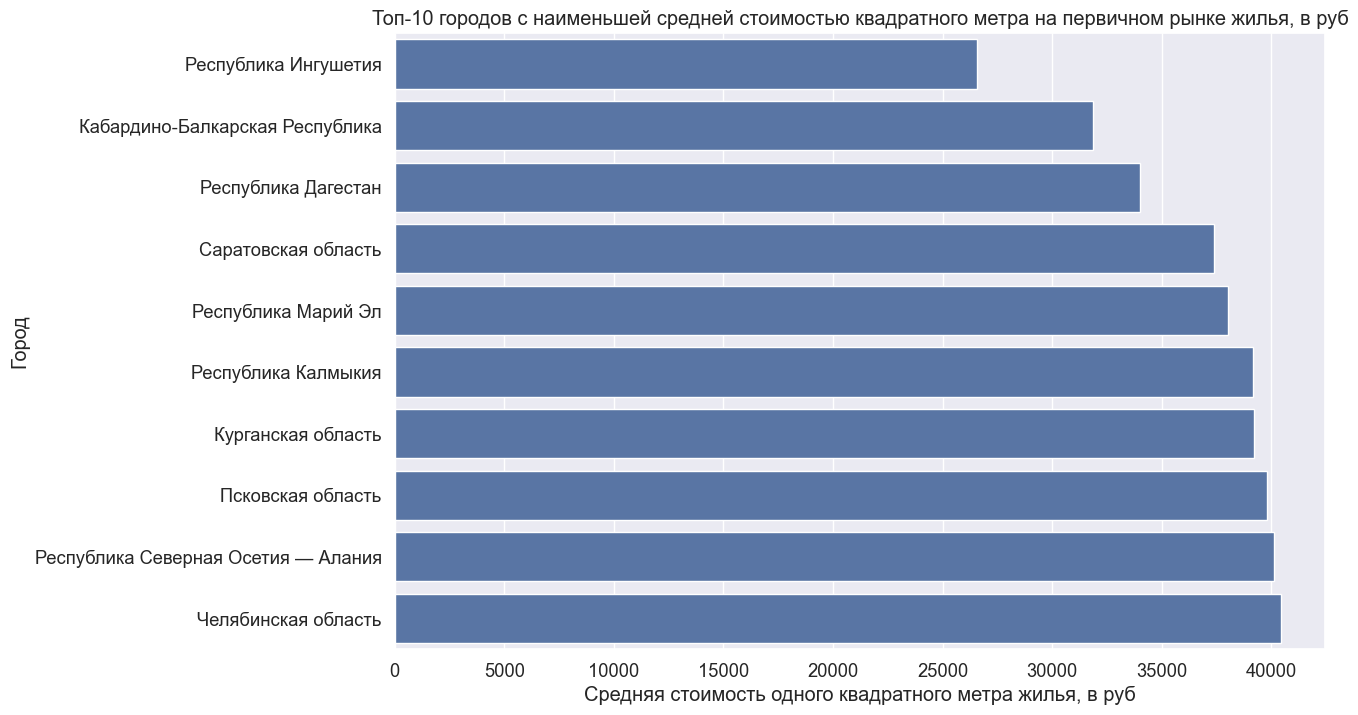

In [105]:
rep5 = data_n.pivot_table(index='reg_name', columns='object_type', aggfunc='mean', values='price_1kv_m').sort_values(by='0', ascending=True).head(10).reset_index()
display(rep5)
sns.barplot(data=rep5,x='0',y='reg_name', orient='h').set(title='Топ-10 городов с наименьшей средней стоимостью квадратного метра на первичном рынке жилья, в руб', xlabel='Средняя стоимость одного квадратного метра жилья, в руб',ylabel='Город')

object_type,reg_name,0,1
0,Республика Ингушетия,26590.05,31404.46
1,Республика Калмыкия,39174.57,34404.47
2,Курганская область,39205.78,36393.94
3,Псковская область,39809.46,36955.16
4,Челябинская область,40431.89,37583.16
5,Республика Марий Эл,38036.17,38208.30
6,Ивановская область,45453.84,38557.40
7,Кемеровская область,45004.13,40462.37
8,Брянская область,44332.52,40808.29
9,Республика Северная Осетия — Алания,40129.59,40837.70


[Text(0.5, 1.0, 'Топ-10 городов с наименьшей средней стоимостью квадратного метра на вторичном рынке жилья, в руб'),
 Text(0.5, 0, 'Средняя стоимость одного квадратного метра жилья, в руб'),
 Text(0, 0.5, 'Город')]

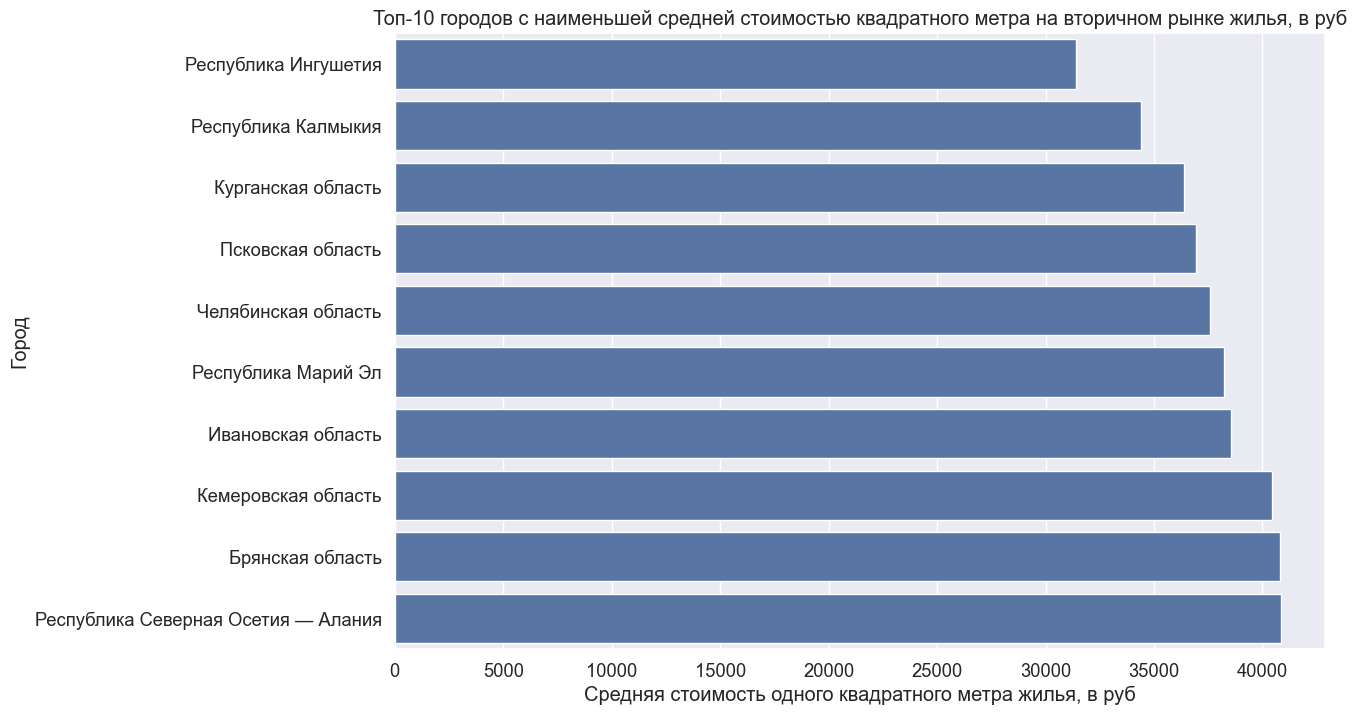

In [106]:
rep5 = data_n.pivot_table(index='reg_name', columns='object_type', aggfunc='mean', values='price_1kv_m').sort_values(by='1', ascending=True).head(10).reset_index()
display(rep5)
sns.barplot(data=rep5,x='1',y='reg_name', orient='h').set(title='Топ-10 городов с наименьшей средней стоимостью квадратного метра на вторичном рынке жилья, в руб', xlabel='Средняя стоимость одного квадратного метра жилья, в руб',ylabel='Город')

,level,price_1kv_m
0,1,62420.49
1,2,71987.56
2,3,73190.65
3,4,73353.20
4,5,71628.56
5,6,80510.16
6,7,82009.59
7,8,79685.24
8,9,78293.61
9,10,78548.63


[Text(0.5, 1.0, 'Cредняя стоимость квадратного метра жилья в зависимости от этажа, в руб'),
 Text(0.5, 0, 'Этаж'),
 Text(0, 0.5, 'Средняя стоимость одного квадратного метра жилья, в руб')]

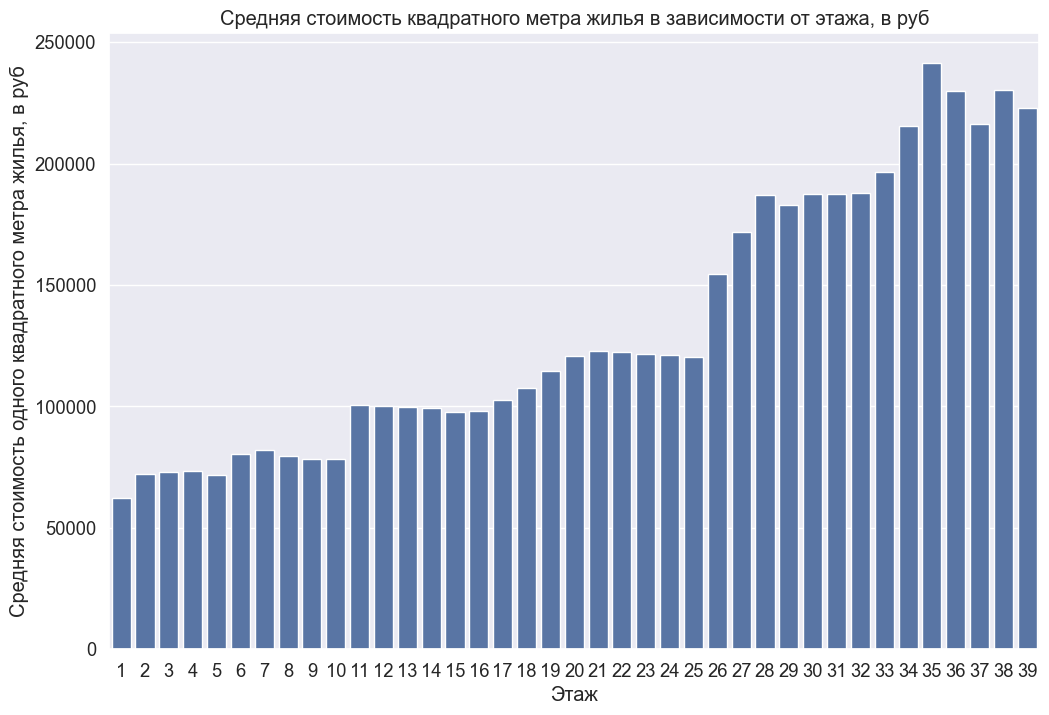

In [115]:
data_n['level'] = data_n['level'].astype('int')
rep6 = data_n.pivot_table(index='level', aggfunc='mean', values='price_1kv_m').reset_index()
display(rep6)
sns.barplot(data=rep6,x='level',y='price_1kv_m').set(title='Cредняя стоимость квадратного метра жилья в зависимости от этажа, в руб', xlabel='Этаж',ylabel='Средняя стоимость одного квадратного метра жилья, в руб')

,rooms,price_1kv_m
0,-1,85391.37
1,1,78406.70
2,2,78005.31
3,3,76441.84
4,4,84258.29
5,5,105999.33
6,6,148773.15
7,7,133503.90
8,8,138695.43
9,9,106786.87


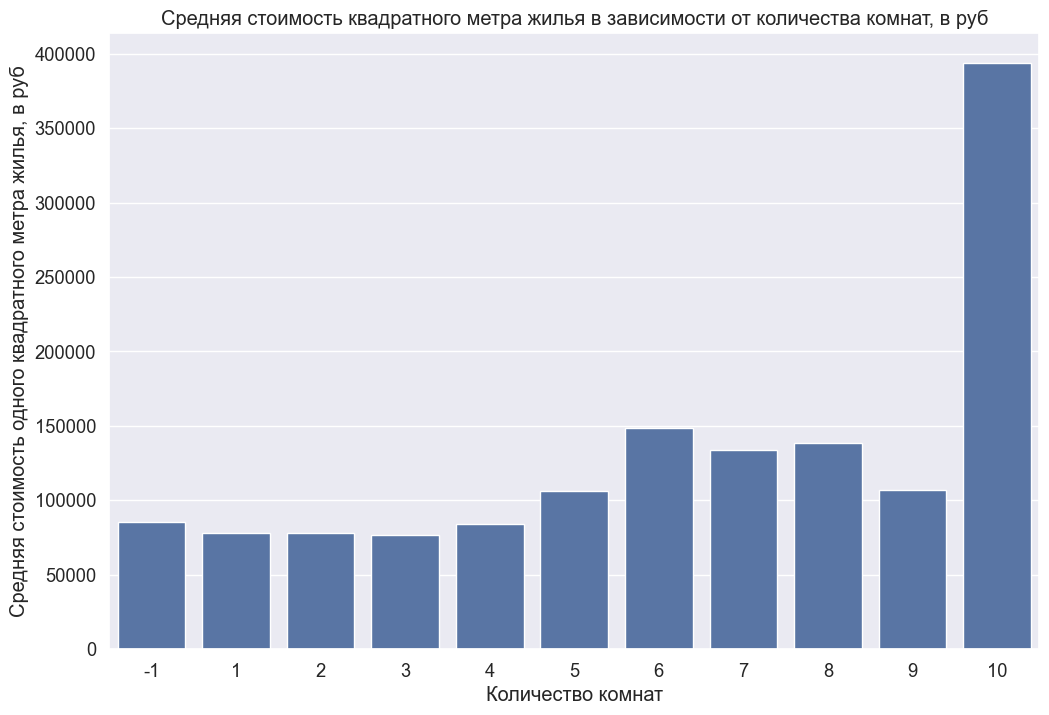

In [108]:
data_n['rooms'] = data_n['rooms'].astype('int')
rep7 = data_n.pivot_table(index='rooms', aggfunc='mean', values='price_1kv_m').sort_values(by='rooms',ascending=True).reset_index()
display(rep7)
sns.barplot(data=rep7,x='rooms',y='price_1kv_m').set(title='Cредняя стоимость квадратного метра жилья в зависимости от количества комнат, в руб', xlabel='Количество комнат',ylabel='Средняя стоимость одного квадратного метра жилья, в руб')
data_n['rooms'] = data_n['rooms'].astype('str')

object_type,rooms,0,1
0,-1,73898.99,95934.31
1,1,84384.96,75692.04
2,2,89733.72,73851.45
3,3,86428.18,73410.15
4,4,132599.15,77332.82
5,5,141817.20,102197.28
6,6,169666.93,146332.03
7,7,109741.81,136139.95
8,8,91236.89,141226.55
9,9,72634.33,111778.39


<Axes: title={'center': 'Cредняя стоимость одного квадратного метра жилья в зависимости от количества комнат и рынка, в руб'}, xlabel='Количество комнат', ylabel='Средняя стоимость одного квадратного метра жилья, в руб'>

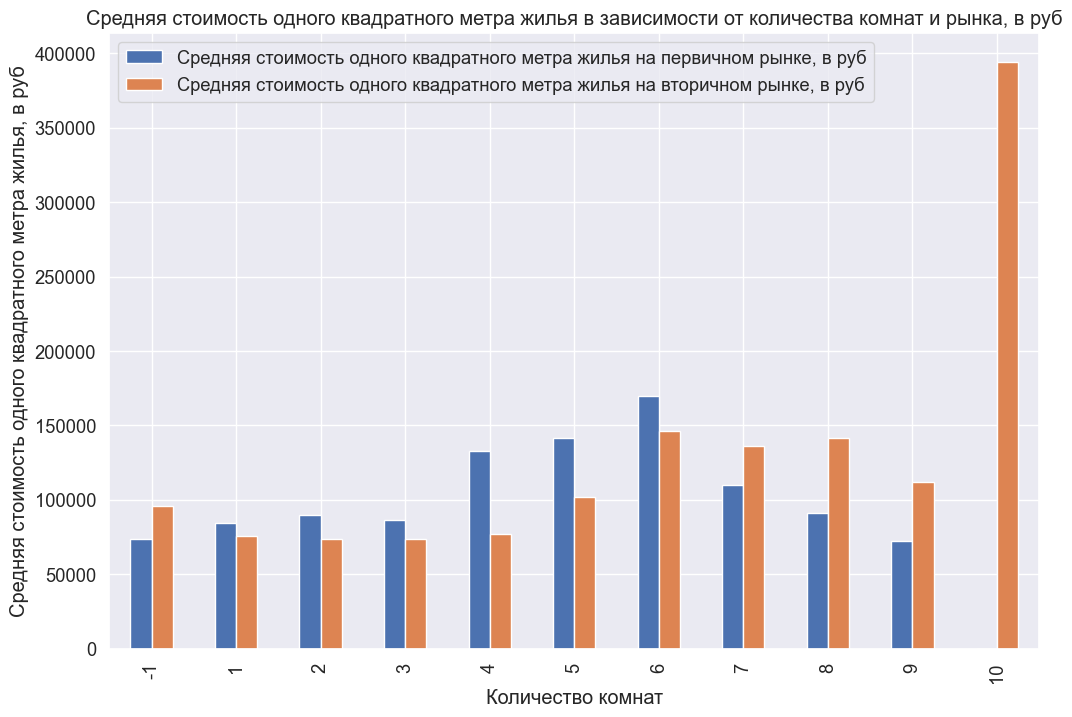

In [109]:
data_n['rooms'] = data_n['rooms'].astype('int')
rep7 = data_n.pivot_table(index='rooms', columns='object_type', aggfunc='mean', values='price_1kv_m').sort_values(by='rooms',ascending=True).reset_index()
display(rep7)
data_n['rooms'] = data_n['rooms'].astype('str')
rep7 = rep7.fillna(0)
# строим столбчатую диаграмму
rep7.plot(kind='bar',x='rooms',y=['0','1'],label=['Средняя стоимость одного квадратного метра жилья на первичном рынке, в руб','Средняя стоимость одного квадратного метра жилья на вторичном рынке, в руб'],title='Cредняя стоимость одного квадратного метра жилья в зависимости от количества комнат и рынка, в руб', xlabel='Количество комнат',ylabel='Средняя стоимость одного квадратного метра жилья, в руб')

,levels,price_1kv_m
0,1,38782.25
1,2,39364.41
2,3,54051.33
3,4,67164.92
4,5,60583.18
5,6,78496.51
6,7,97329.59
7,8,115846.73
8,9,74147.27
9,10,52496.36


[Text(0.5, 1.0, 'Cредняя стоимость квадратного метра жилья в зависимости от количества этажей в доме, в руб'),
 Text(0.5, 0, 'Количество этажей в доме'),
 Text(0, 0.5, 'Средняя стоимость одного квадратного метра жилья, в руб')]

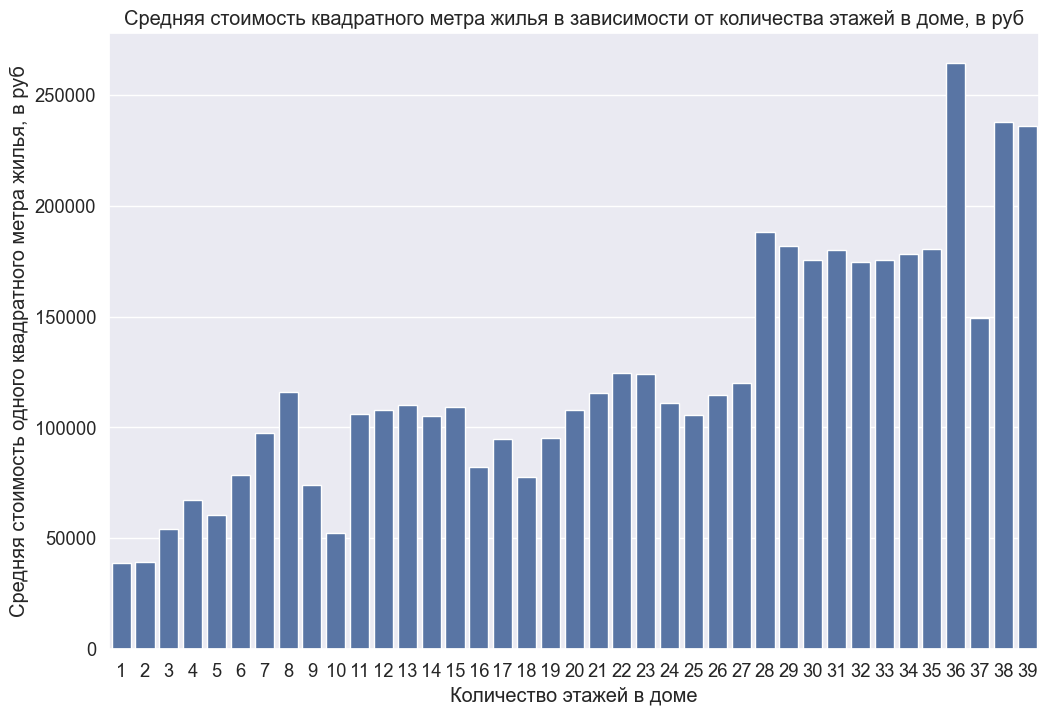

In [116]:
data_n['levels'] = data_n['levels'].astype('int')
rep6 = data_n.pivot_table(index='levels', aggfunc='mean', values='price_1kv_m').reset_index()
display(rep6)
sns.barplot(data=rep6,x='levels',y='price_1kv_m').set(title='Cредняя стоимость квадратного метра жилья в зависимости от количества этажей в доме, в руб', xlabel='Количество этажей в доме',ylabel='Средняя стоимость одного квадратного метра жилья, в руб')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82],
 [Text(0, 0, 'Алтайский край'),
  Text(1, 0, 'Амурская область'),
  Text(2, 0, 'Архангельская область'),
  Text(3, 0, 'Астраханская область'),
  Text(4, 0, 'Белгородская область'),
  Text(5, 0, 'Брянская область'),
  Text(6, 0, 'Владимирская область'),
  Text(7, 0, 'Волгоградская область'),
  Text(8, 0, 'Вологодская область'),
  Text(9, 0, 'Воронежская область'),
  Text(10, 0, 'Еврейская автономная область'),
  Text(11, 0, 'Забайкальский край'),
  Text(12, 0, 'Ивановская область'),
  Text(13, 0, 'Иркутская

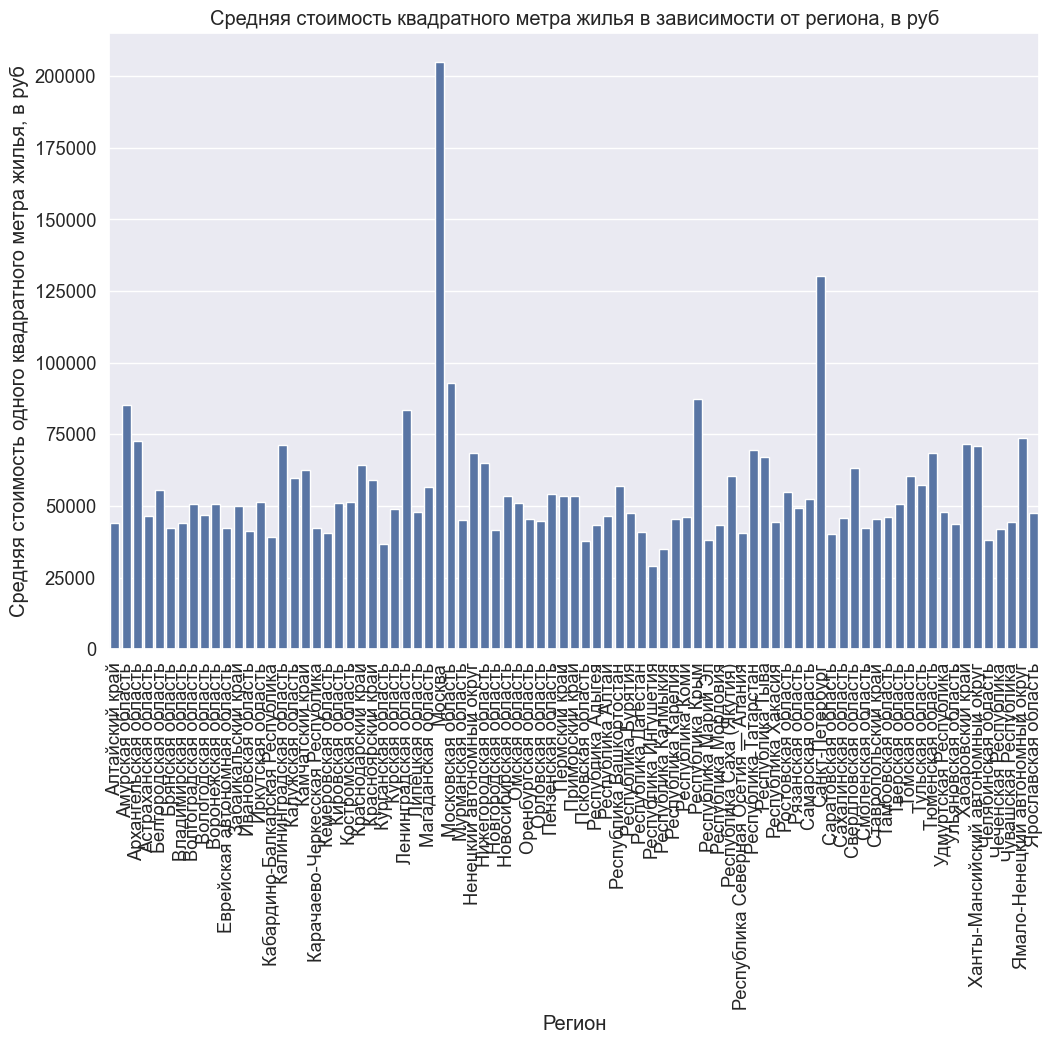

In [111]:
rep6 = data_n.pivot_table(index='reg_name', aggfunc='mean', values='price_1kv_m').reset_index()
sns.barplot(data=rep6,x='reg_name',y='price_1kv_m').set(title='Cредняя стоимость квадратного метра жилья в зависимости от региона, в руб', xlabel='Регион',ylabel='Средняя стоимость одного квадратного метра жилья, в руб')
plt.xticks(rotation=90) 

In [112]:
data_n['price_1kv_m'].describe()

count   5133951.00
mean      78545.04
std       54907.54
min          84.00
25%       44642.86
50%       62054.79
75%       92447.92
max      618340.55
Name: price_1kv_m, dtype: float64

In [113]:
data_n['object_type'] = data_n['object_type'].astype('int')
data_n[['price_1kv_m','area','kitchen_area','object_type']].corr()

,price_1kv_m,area,kitchen_area,object_type
price_1kv_m,1.00,0.09,0.18,-0.09
area,0.09,1.00,0.53,-0.01
kitchen_area,0.18,0.53,1.00,-0.20
object_type,-0.09,-0.01,-0.20,1.00


<Axes: >

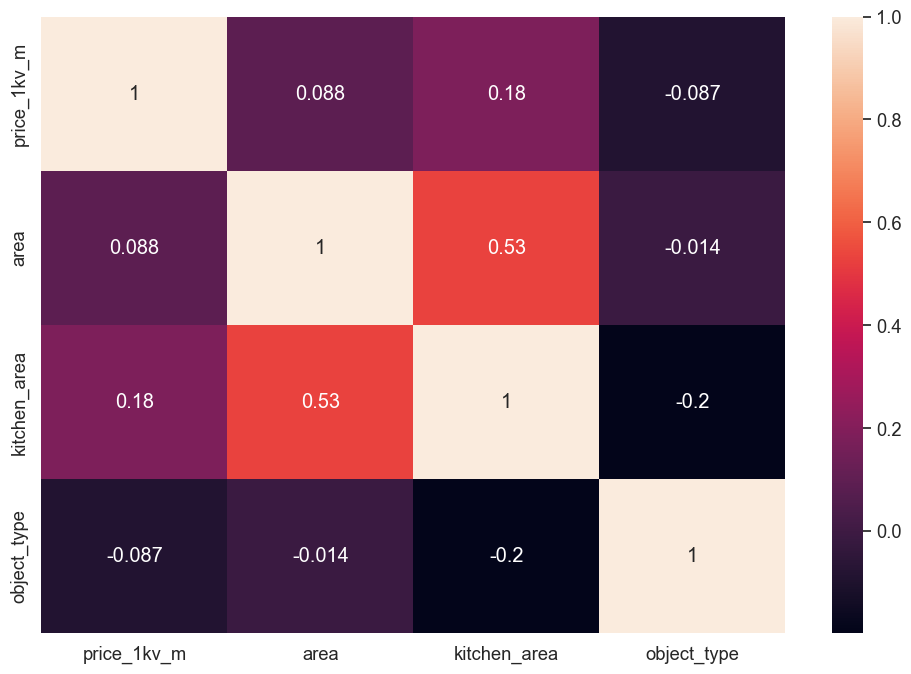

In [114]:
sns.heatmap(data_n[['price_1kv_m','area','kitchen_area','object_type']].corr(), annot=True)

#### Вывод по заданию №5:
1. Анализ средней цены за 1 квадратный метр жилья за период с начала 2018 года по май 2021 года показывает устойчивый рост, особенно начиная со второй половины 2020 года. Несмотря на кратковременное снижение весной, начиная с лета 2020 года можно наблюдать резкий рост цен, который продолжается до конца года. Такой резкий рост может быть связан с запуском в России льготной ипотечной программы, а также снижением ключевой ставки до своего минимума. Тогда спрос на жильё резко увеличился, а предложение в краткосрочном периоде жёстко ограничено и не успевает за спросом, из-за чего цена начинает расти. Кроме того, начинает действовать эффект ожиданий, когда люди ожидают дальнейшего роста цен и начинает покупать квартиру «пока не подорожало ещё больше», что дополнительно повышает цены.
2. Динамика средней стоимости одного квадратного метра жилья в зависимости от типа рынка повторяет общую динамику средней цены за 1 квадратный метр жилья. В период с 2018 по 2021 год цены за 1 квадратный метр росли как на первичном, так и на вторичном рынке, однако в некоторые моменты темпы роста существенно различались. На графике можно увидеть, что первичный рынок показывает более высокую волатильность, причем в 2018-2019 году цена на нем была в большинстве случаев ниже или примерно равна цене на вторичным рынке. На вторичном рынке относительно первичного можно увидеть стабильную динамику цен с небольшими колебаниями. Со второй половины 2020 года можно увидеть, что цены, как на первичном, так и на вторичном начинают расти очень быстро, однако на первичном рынке они растут быстрее. И у же к маю 2021 года разрыв между ценами на рынках очень сильно увеличивается. Такую динамику можно объяснить несколькими причинами. Во-первых, та самая льготная ипотеку, которую ввели в 2020 году, в первую очередь была направлена на первичный рынок, из-за чего резко вырос спрос на квартиры в новостройках и, следовательно, выросла цена. Кроме того, как было сказано ранее, предложение на первичном рынке в краткосрочном периоде жёстко ограничено и не успевает за спросом, из-за чего цена начинает очень быстро расти.
3. Также была проанализирована средняя стоимость одного одного квадратного метра жилья в зависимости от типа дома. Анализ показал, что кирпично-монолитные дома имеют наибольшую среднюю цену - около 112 тысяч рублей за квадратный метр, что можно объяснить более высокой прочностью, долговечностью, тепло и звукоизоляцией по сравнению с другими типами домов. Кроме того, кирпично-монолитные дома чаще строятся в новых жилых комплексах, в хороших районах и они относительно новые, из-за чего их цена может быть выше. Панельные, кирпичные и блочные дома находятся в среднем ценовом сегменте (около 65-70 тысяч рублей за 1 квадратный метр). А деревянные дома имеют наименьшую стоимость - около 42 тысяч рублей за 1 квадратный метр, что может быть обусловлено более низкой долговечностью и уровнем комфорта. Причем квартиры в типе дома «другое» имеют более высокий уровень цен по сравнению с другими типами домов, что может быть связано с неоднородностью данных в этой группе.
4. Если рассматривать среднюю стоимость одного одного квадратного метра жилья в по типам домов в зависимости от рынка, в некоторых моментах можно наблюдать сильные различия. Кирпично-монолитные дома являются самыми дорогими в обоих сегментах, при этом на первичном рынке цена выше, чем на вторичном, что можно объяснить тем, что на первичном рынке более новые объекты с более высоким уровнем комфорта. Панельные и блочные дома на вторичном рынке стоят заметно дороже, чем на первичном. Кирпичные дома и категория домов «другое» имеют примерно одинаковые цены на на первичном и вторичном рынках. Однако на цены на деревянные дома на первичном рынке существенно выше, чем на вторичном. Это можно объяснить тем, что если строят новые деревянные дома, то это дома высшего класса в достаточно элитных районах, поселках. А деревянные дома на вторичном рынке это в основном старые затхлые дома, которые продают в различных деревнях.
5. Также была рассмотрена динамика средней стоимости одного квадратного метра жилья в зависимости от типа дома. Можно наблюдать, что цены квартир всех видов домов растут со второй половины 2020 года, однако быстрее всего растут цены на квартиры в кирпично-монолитных домах, а менее быстро растут цены на квартиры в блочном жилье.
6. Также были рассмотрены топ-10 регионов с наибольшей средней стоимостью 1 квадратного метра жилья. Лидером по уровню цен на жильё является Москва, где средняя стоимость одного квадратного метра превышает 200 тысяч рублей. На втором месте располагается Санкт-Петербург со средней ценой около 130 тысяч рублей за 1 квадратный метр, уступая по цене Москве, но значительно превышая цены в остальных регионах. Остальные регионы характеризуются средней ценой от 70 до 93 тысяч рублей за 1 квадратный метр. В Москве и Санкт-Петербурге цена выше, чем в остальных регионах, так как эти города самые быстрорастущие с постоянной нехваткой предложения относительно большого спроса.
7. Также были рассмотрены топ-10 регионов с наименьшей средней стоимостью 1 квадратного метра жилья. Наименьшая средняя стоимость квадратного метра жилья наблюдается в Республике Ингушетия - около 29 тыс. рублей, что значительно ниже среднего уровня. Остальные регионы, такие как Республика Калмыкия, Курганская, Псковская область и другие имеют средние цены в диапазоне от 38 до 41 тысяч рублей за 1 квадратный метр. Такую низкую стоимость можно объяснить более низким уровнем экономической активности и тем самым спроса на рынке недвижимости.
8. Категоризация топ-10 регионов с наименьшей и наибольшей средней стоимостью одного квадратного метра жилья по сегментам рынка в целом совпадает с ранее полученными общими выводами и не демонстрирует существенных отличий.
9. Кроме того, была проанализирована средняя стоимость квадратного метра жилья в зависимости от этажа квартиры. Можно наблюдать, что с увеличением этажа, на котором находится квартира, средняя стоимость одного квадратного метра жилья начинает расти. Это объясняется тем, что квартиры на более высоких этажах часто имеют более привлекательный вид из окон, что повышает их ценность. Кроме того, чем выше этаж, тем слабее влияние уличного шума, выхлопных газов и пыли, особенно в крупных городах. Также квартиры на высоких этажах чаще встречаются в новых домах, которые в среднем стоят дороже, чем старые жилые дома. Однако, если с первым этажом все понятно, то насчет последних этажей необходимо отметить то, что в отдельных случаях такие этажи могут также оцениваться ниже из-за недостатков (например, очень жарко летом и очень холодно зимой; протечка крыш; слишком долго спускаться до первого этажа и тд). Также была проанализирована средняя стоимость квадратного метра жилья в зависимости от количества этажей в доме. Она повторяет динамику средней стоимости квадратного метра жилья в зависимости от этажа квартиры.
10. Также была проанализирована средняя стоимость квадратного метра жилья в зависимости от количества комнат. В среднем, цена за квадратный метр возрастает с увеличением числа комнат, достигая максимума в 150 тысяч рублей при 6 комнатах, если не учитывать квартиры с 10 комнатами, после чего цена начинает немного снижаться, но все равно оставаясь выше, чем в квартирах с 1-4 комнатами. Категоризация по типу рынка в целом повторяет общую динамику. Можно увидеть, что квартиры с 1-6 комнатами на первичном рынке дороже, чем на вторичном рынке, а квартиры с 7-10 комнатами, а также студии дороже на вторичном рынке. Это объясняется тем, что новые дома в основном ориентированы на массового покупателя с обычным количеством комнат, тогда как вторичный рынок включает больше квартир с необычным числом комнат или большей площадью.
11. Корреляционный анализ показывает, что между большинством переменных наблюдается слабая линейная связь. Стоимость 1 квадатного метра жилья слабо коррелирует как с общей площадью, так и с площадью кухни и типом объекта. Между общей площадью и площадью кухни наблюдается умеренная положительная связь, что является логичным результатом: в более крупных квартирах, как правило, больше кухня. Связи между типом объекта и площадями слабые или практически отсутствуют.